# mCREAM Graph Module Ensemble Analysis

Architecture: M Concept-Concept blocks (one per expert graph), shared backbone/side-channel/task-head.
Aggregation at **concept level** `c = mean(c_0..c_M)`, not prediction level.

## Three experiment types:
1. **Noisy DAGs** — same action/level, different random seeds per expert
2. **Single-edge perturbation** — each expert missing/adding exactly 1 edge
3. **Mixed noise levels** — experts from low/medium/high, λ can learn


In [ ]:
import pandas as pd, numpy as np, ast, torch
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings; warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

ACTION_COLOR  = {'deletion':'#e74c3c','addition':'#2ecc71','reversal':'#3498db'}
LEVEL_ALPHA   = {'low':0.45,'medium':0.70,'high':1.0}
LEVEL_COLOR   = {'low':'#3498db','medium':'#e67e22','high':'#e74c3c'}

EXPERIMENTS_ROOT = Path('/home/dani00003/mCREAM/experiments')
GRAPHS_ROOT      = Path('/home/dani00003/mCREAM/data/FashionMNIST')
DAG_CFMNIST      = GRAPHS_ROOT / 'Complete_Concept_FMNIST_DAG.csv'

# ── Dataset registry — add CUB here once data is ready ───────────────────────
DATASET_CONFIG = {
    'Complete_Concept_FMNIST': {
        'dag':         DAG_CFMNIST,
        'num_concepts': 11,
        'graphs_root':  GRAPHS_ROOT,
    },
    'CelebA': {
        'dag':         Path('/home/dani00003/mCREAM/data/CelebA/final_DAG_unfair.csv'),
        'num_concepts': 7,
        'graphs_root':  Path('/home/dani00003/mCREAM/data/CelebA'),
    },
    'CUB': {
        'dag':         Path('/home/dani00003/mCREAM/data/CUB/CUB_DAG_only_Gc.csv'),
        'num_concepts': 112,
        'graphs_root':  Path('/home/dani00003/mCREAM/data/CUB'),
    },
}

DATASETS = ['Complete_Concept_FMNIST', 'CelebA']
ACTIONS  = ['deletion','addition','reversal']
LEVELS   = ['low','medium','high']
N_EXPERTS = 5

# ── Shared helpers ────────────────────────────────────────────────────────────
def load_gt_cream(root):
    rows=[]
    for ds,model,exp in [('Complete_Concept_FMNIST','Standard_FashionMNIST','CREAM_best_cfmnist')]:
        md=root/ds/'train_cbm'/model/exp/'last_metrics'
        if not md.exists(): continue
        for f in sorted(md.glob('*.csv')):
            df=pd.read_csv(f); df['dataset']=ds; rows.append(df)
    gt=pd.concat(rows,ignore_index=True) if rows else pd.DataFrame()
    if len(gt)>0:
        r=gt.iloc[0]
        print(f'GT CREAM: acc={r.get("test_task_accuracy",float("nan")):.4f}  '
              f'concept={r.get("test_concept_accuracy",float("nan")):.4f}  CCI={r.get("CCI","N/A")}')
    return gt

def load_interventions(root, exp_name_filter=None, datasets=None):
    rows=[]
    search_ds = datasets or DATASETS
    for ds in search_ds:
        ens_dir=root/ds/'train_cbm'/'mCREAM_GraphEnsemble'
        if not ens_dir.exists(): continue
        for csv_f in ens_dir.rglob('intervention_results.csv'):
            try:
                df=pd.read_csv(csv_f)
                parts=csv_f.parts
                exp_name=seed=None
                for i,p in enumerate(parts):
                    if p=='mCREAM_GraphEnsemble' and i+1<len(parts): exp_name=parts[i+1]
                    if p.startswith('seed_'): seed=int(p.split('_')[1])
                if exp_name is None: continue
                if exp_name_filter and not any(f in exp_name for f in exp_name_filter): continue
                df['dataset']=ds; df['exp_name']=exp_name; df['seed']=seed
                rows.append(df)
            except: pass
    return pd.concat(rows,ignore_index=True) if rows else pd.DataFrame()

def show_expert_dags(dirs_and_indices, title, K=11, dag_path=None):
    """Show expert graphs. dag_path overrides default cfmnist GT."""
    gt_path = dag_path or DAG_CFMNIST
    gt_df = pd.read_csv(gt_path, index_col=0)
    gt_vals = (gt_df.values!=0).astype(int)
    gt_u2c  = gt_vals[:K, :K]

    M=len(dirs_and_indices)
    fig,axes=plt.subplots(1,M+1,figsize=(2.5*(M+1),3))
    fig.suptitle(title,fontsize=10,fontweight='bold')

    def make_rgb(p):
        rgb=np.zeros((*p.shape,3))
        for r in range(p.shape[0]):
            for c in range(p.shape[1]):
                if   gt_u2c[r,c]==1 and p[r,c]==1: rgb[r,c]=[0.2,0.4,0.8]
                elif gt_u2c[r,c]==0 and p[r,c]==1: rgb[r,c]=[0.2,0.8,0.2]
                elif gt_u2c[r,c]==1 and p[r,c]==0: rgb[r,c]=[0.9,0.2,0.2]
                else: rgb[r,c]=[0.93,0.93,0.93]
        return rgb

    gt_rgb=np.zeros((*gt_u2c.shape,3))
    for r in range(K):
        for c in range(K):
            gt_rgb[r,c]=[0.2,0.4,0.8] if gt_u2c[r,c]==1 else [0.93,0.93,0.93]
    axes[0].imshow(gt_rgb,aspect='auto',interpolation='nearest')
    axes[0].set_title('GT',fontweight='bold',fontsize=8)
    for sp in axes[0].spines.values(): sp.set_edgecolor('gold'); sp.set_linewidth(3)
    axes[0].set_xticks([]); axes[0].set_yticks([])

    for m,(graph_dir,idx,label) in enumerate(dirs_and_indices):
        f=Path(graph_dir)/'u2c'/f'expert_{idx}.pt'
        ax=axes[m+1]
        if not f.exists(): ax.text(0.5,0.5,'N/A',ha='center',va='center',transform=ax.transAxes,fontsize=8); ax.axis('off'); continue
        p=torch.load(f,weights_only=True).float().numpy()
        # clip to K×K in case graph is larger
        p=p[:K,:K]
        ax.imshow(make_rgb(p),aspect='auto',interpolation='nearest')
        ax.set_title(label,fontsize=7)
        ax.set_xticks([]); ax.set_yticks([])

    from matplotlib.patches import Patch
    fig.legend(handles=[Patch(facecolor=[0.2,0.4,0.8],label='kept'),
                         Patch(facecolor=[0.9,0.2,0.2],label='deleted'),
                         Patch(facecolor=[0.2,0.8,0.2],label='added')],
               loc='lower center',ncol=3,fontsize=7,bbox_to_anchor=(0.5,-0.05))
    plt.tight_layout(rect=[0,0.05,1,1])
    plt.show()

gt_df = load_gt_cream(EXPERIMENTS_ROOT)
print(f'Root exists: {EXPERIMENTS_ROOT.exists()}')

---
# Experiment 1 — Noisy DAGs (same level, different seeds)

M=5 experts, each with same noise type+level but different random seed → different specific edges.

## Two intervention modes (shown separately below)

**Individual concept interventions** (`group_interventions=False`):
- Replace one concept at a time, randomly chosen
- x-axis goes 0 → 11 (one per concept)
- Answers: *how much does each extra concept fix help?*

**Group interventions** (`group_interventions=True`):
- Replace all concepts in one mutex group at once (cfmnist has 3 groups)
- x-axis goes 0 → 3 (one per mutex group)
- One step = revealing a full mutually-exclusive set (e.g. all Season concepts together)
- Answers: *how much does fixing a whole semantic group help?*
- Steeper curve = model relies more on that semantic group for prediction

In [2]:
def load_noisy_dag_results(root):
    rows=[]
    for ds in DATASETS:
        ens_dir=root/ds/'train_cbm'/'mCREAM_GraphEnsemble'
        if not ens_dir.exists(): continue
        for exp_dir in sorted(ens_dir.iterdir()):
            if not exp_dir.is_dir(): continue
            name=exp_dir.name
            if not name.startswith('graph_ensemble_') or 'mixed' in name or 'gensemble' in name: continue
            p=name.split('_')
            try: action=p[2]; level=p[3]
            except: continue
            for seed_dir in sorted(exp_dir.glob('seed_*/lightning_logs/version_*')):
                seed=int(seed_dir.parent.parent.name.split('_')[1])
                for csv_f in sorted(seed_dir.glob('*.csv')):
                    if any(x in csv_f.name for x in ['perc_','_set_','intervention','exogenous']): continue
                    try:
                        df=pd.read_csv(csv_f)
                        df['dataset']=ds;df['action']=action;df['noise_level']=level;df['seed']=seed
                        rows.append(df)
                    except: pass
    if not rows: print('No noisy DAG results'); return pd.DataFrame()
    df=pd.concat(rows,ignore_index=True)
    print(f'Exp1 loaded: {len(df)} rows | actions={sorted(df.action.unique())} | levels={sorted(df.noise_level.unique())}')
    return df

exp1_df    = load_noisy_dag_results(EXPERIMENTS_ROOT)
exp1_interv= load_interventions(EXPERIMENTS_ROOT, exp_name_filter=['graph_ensemble_deletion','graph_ensemble_addition','graph_ensemble_reversal'])


Exp1 loaded: 180 rows | actions=['consensus'] | levels=['high', 'low', 'medium']


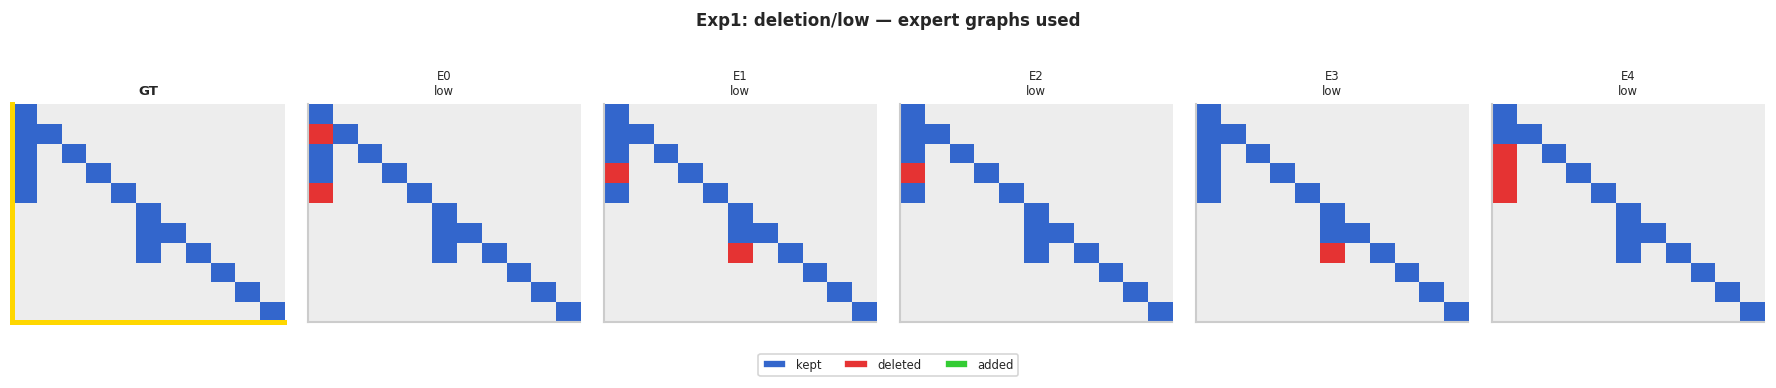

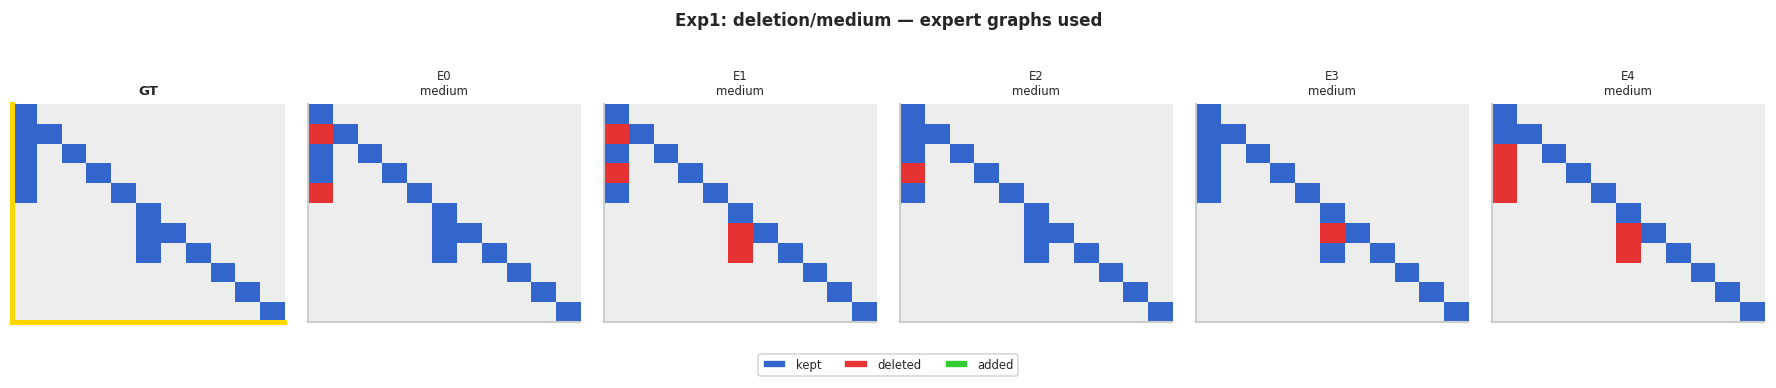

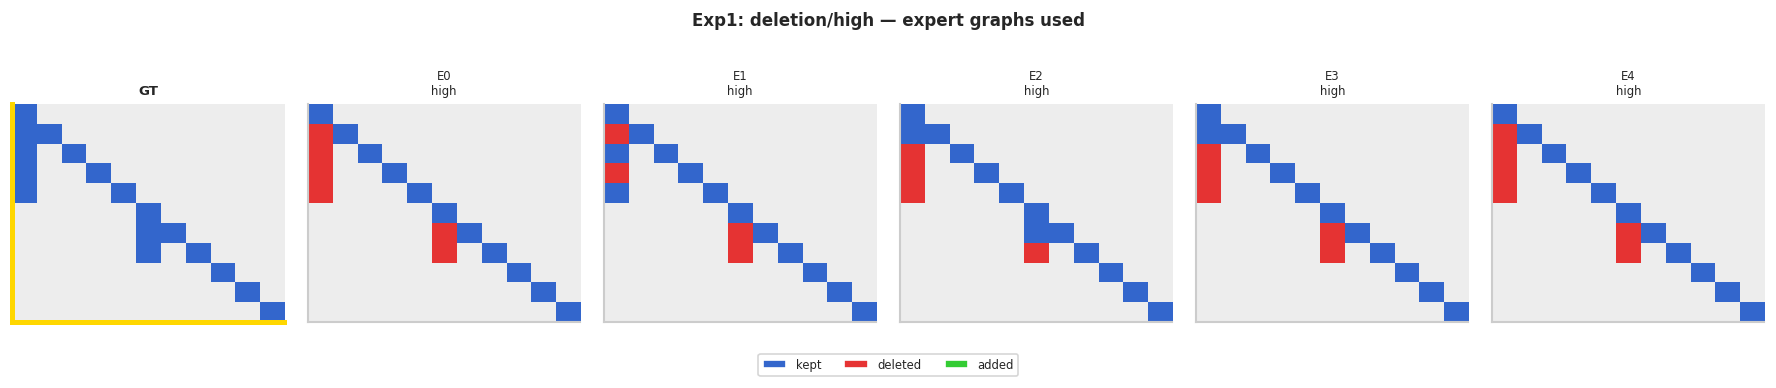

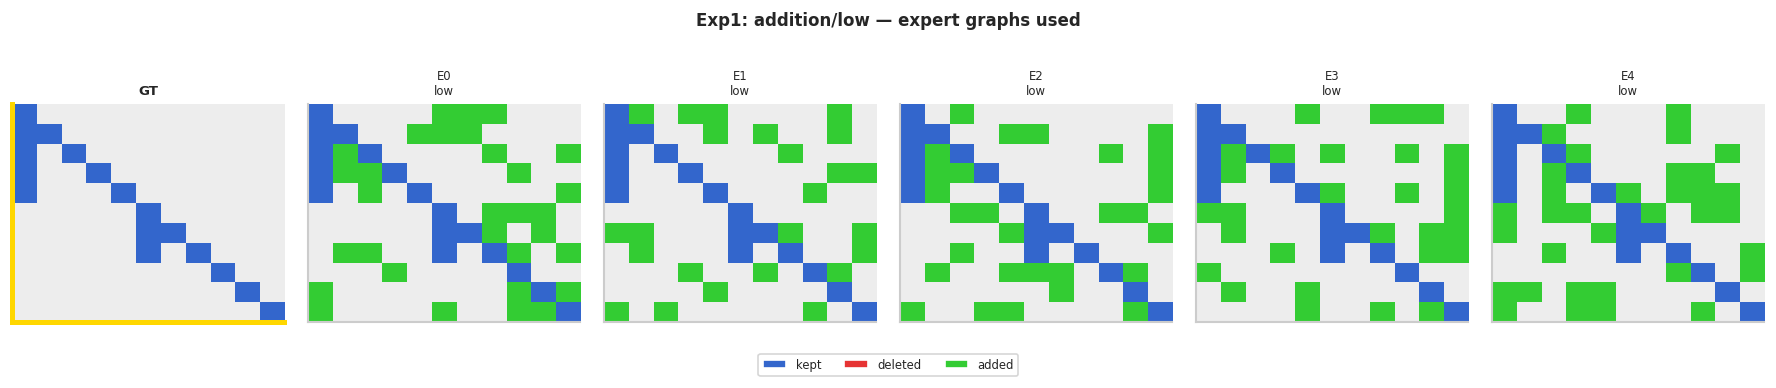

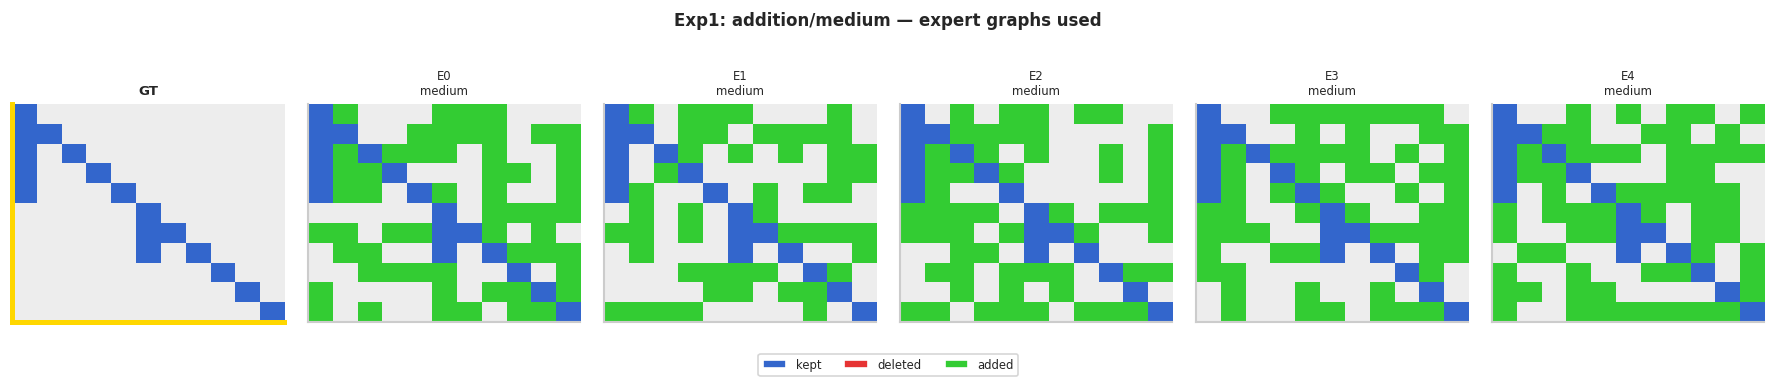

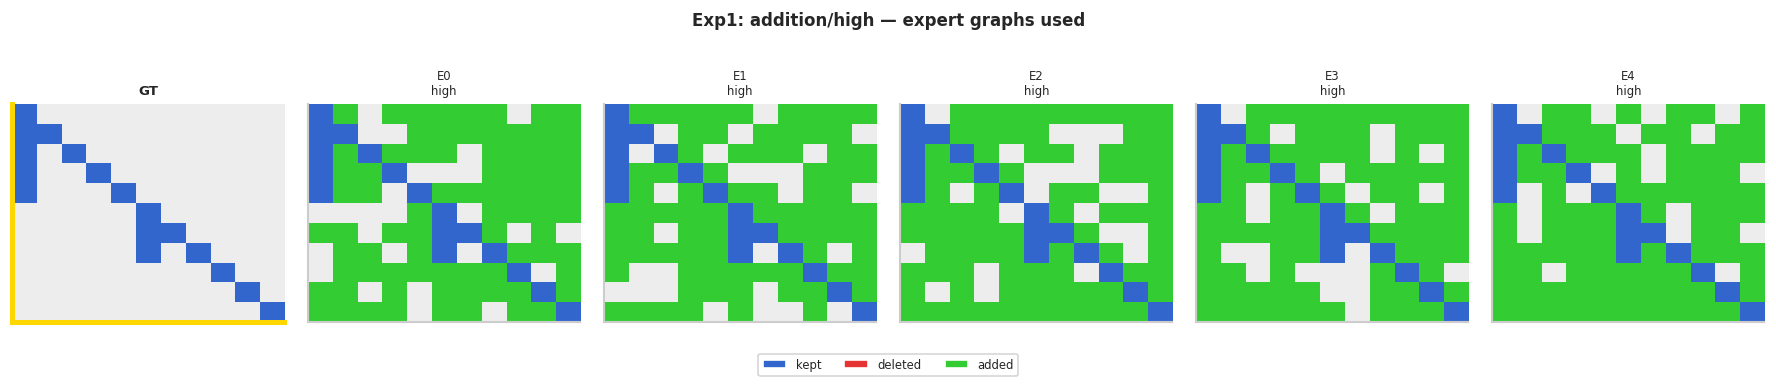

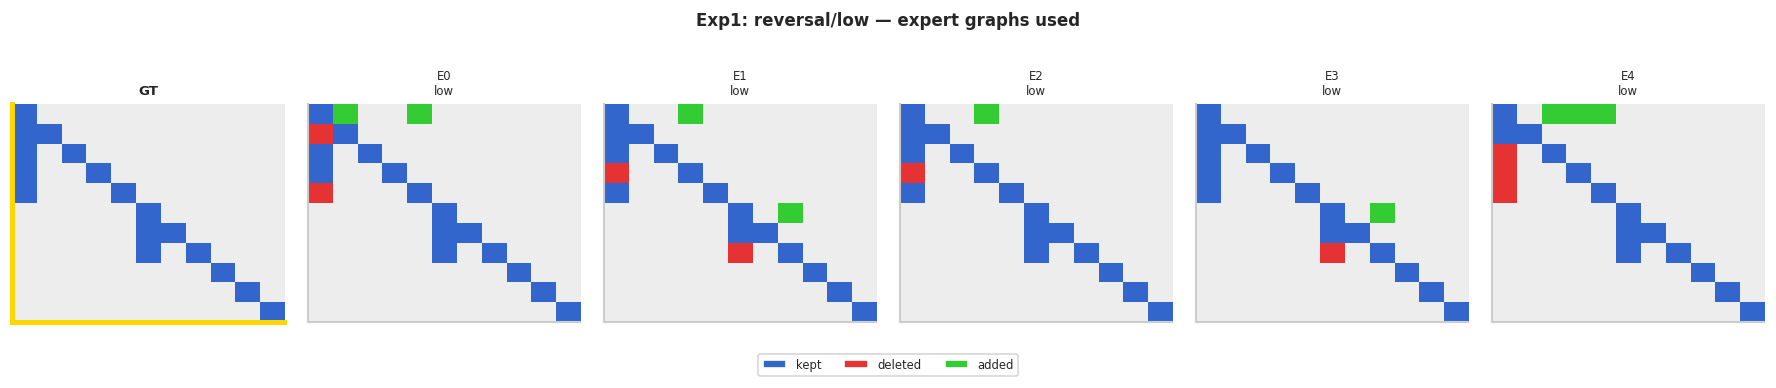

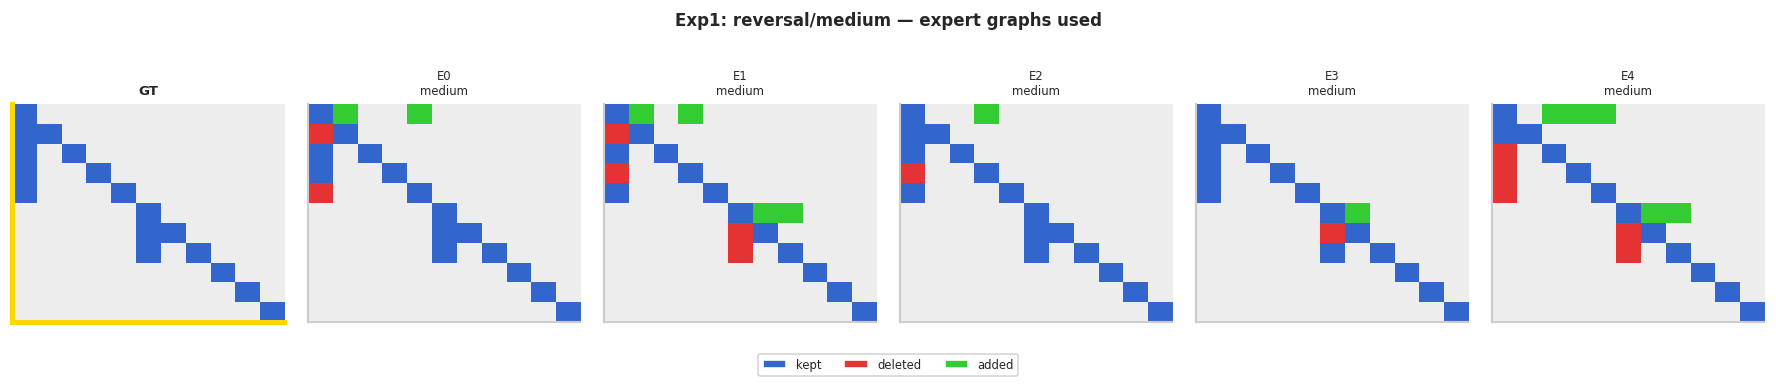

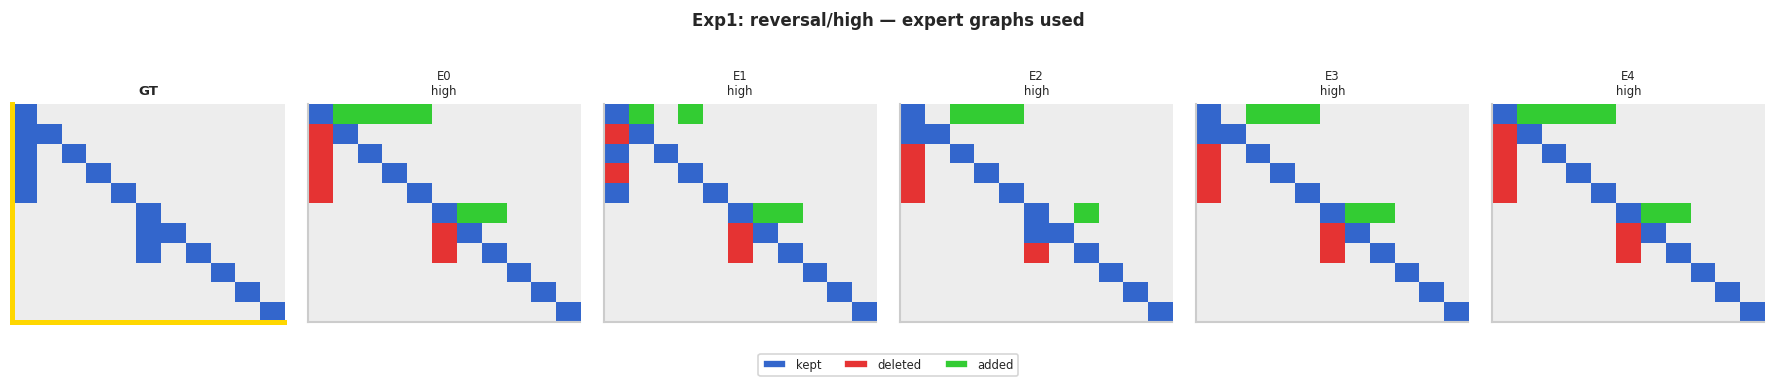

In [4]:
# Show expert graphs for each action/level
graphs_base = GRAPHS_ROOT / 'expert_graphs' / 'ensemble'
for action in ACTIONS:
    for level in LEVELS:
        d = graphs_base / f'{action}_{level}'
        if not d.exists(): continue
        dirs_and_indices = [(d, m, f'E{m}\n{level}') for m in range(N_EXPERTS)]
        show_expert_dags(dirs_and_indices, f'Exp1: {action}/{level} — expert graphs used')


In [ ]:
if len(exp1_df)==0: print('No Exp1 data')
else:
    lnum={'low':0.25,'medium':0.50,'high':0.75}
    KEY=['test_task_accuracy','test_concept_accuracy','CCI','PFI_concept_importance']
    av=[c for c in KEY if c in exp1_df.columns]
    means=exp1_df.groupby(['action','noise_level'])[av].mean()
    stds =exp1_df.groupby(['action','noise_level'])[av].std()
    sm=pd.DataFrame(index=means.index)
    for c in av: sm[c]=means[c].map('{:.4f}'.format)+' +/- '+stds[c].map('{:.4f}'.format)
    if len(gt_df)>0:
        print('GT CREAM baseline:')
        for c in av:
            if c in gt_df.columns: print(f'  {c:30s} {gt_df[c].mean():.4f}')
    print('\n--- Experiment 1: Noisy DAGs ---')
    display(sm)

    # Accuracy vs noise level
    fig,axes=plt.subplots(1,2,figsize=(12,4.5))
    fig.suptitle('Exp1: Noisy DAGs — accuracy vs noise level',fontsize=12,fontweight='bold')
    for ax,metric,ylabel in [(axes[0],'test_task_accuracy','Task Accuracy'),(axes[1],'test_concept_accuracy','Concept Accuracy')]:
        if metric not in exp1_df.columns: continue
        d=exp1_df.copy(); d['noise_prob']=d['noise_level'].map(lnum)
        agg=d.groupby(['action','noise_prob'])[metric].agg(['mean','std']).reset_index()
        for action in ACTIONS:
            sub=agg[agg['action']==action]
            if sub.empty: continue
            col=ACTION_COLOR[action]
            ax.plot(sub['noise_prob'],sub['mean'],color=col,marker='o',markersize=8,lw=2,label=action)
            ax.fill_between(sub['noise_prob'],sub['mean']-sub['std'],sub['mean']+sub['std'],alpha=0.12,color=col)
        if len(gt_df)>0 and metric in gt_df.columns:
            v=gt_df[metric].mean()
            ax.axhline(v,color='black',lw=2,ls='--',label=f'GT CREAM: {v:.4f}')
        ax.set_xlabel('Noise probability'); ax.set_ylabel(ylabel)
        ax.set_xticks([0.25,0.50,0.75]); ax.set_xticklabels(['low','medium','high'])
        ax.legend(title='Noise type',fontsize=8)
    plt.tight_layout(); plt.savefig('exp1_accuracy.png',dpi=150,bbox_inches='tight'); plt.show()

    # ── Intervention curves: TWO plots side by side per action ────────────────
    if len(exp1_interv)>0:
        for action in ACTIONS:
            sub_all = exp1_interv[exp1_interv['exp_name'].str.contains(action)]
            if sub_all.empty: continue

            # Split into individual and group
            has_group_col = 'group_interventions' in sub_all.columns
            sub_indiv = sub_all[sub_all['group_interventions']==False] if has_group_col else sub_all
            sub_group = sub_all[sub_all['group_interventions']==True]  if has_group_col else pd.DataFrame()

            fig, axes = plt.subplots(2, len(LEVELS), figsize=(5*len(LEVELS), 9), sharey='row')
            fig.suptitle(
                f'Exp1: {action} — Intervention curves\n'
                f'TOP: individual concept (0→11)   BOTTOM: group/mutex (0→3)',
                fontsize=11, fontweight='bold'
            )

            for col_idx, level in enumerate(LEVELS):
                # ── TOP ROW: individual interventions ─────────────────────────
                ax_top = axes[0][col_idx]
                lv = sub_indiv[sub_indiv['exp_name'].str.contains(level)]
                if not lv.empty:
                    agg = lv.groupby('num_interventions')['test_task_accuracy'].agg(['mean','std']).reset_index()
                    ax_top.plot(agg['num_interventions'], agg['mean'],
                                color=ACTION_COLOR[action], lw=2.5, marker='o', markersize=5)
                    ax_top.fill_between(agg['num_interventions'],
                                        agg['mean']-agg['std'], agg['mean']+agg['std'],
                                        alpha=0.15, color=ACTION_COLOR[action])
                ax_top.set_title(f'{level} — individual', fontsize=10)
                ax_top.set_xlabel('Concepts replaced (0→11)')
                ax_top.set_ylabel('Task Accuracy' if col_idx==0 else '')
                ax_top.tick_params(labelsize=8)

                # ── BOTTOM ROW: group interventions ───────────────────────────
                ax_bot = axes[1][col_idx]
                lv_g = sub_group[sub_group['exp_name'].str.contains(level)]
                if not lv_g.empty:
                    agg_g = lv_g.groupby('num_interventions')['test_task_accuracy'].agg(['mean','std']).reset_index()
                    ax_bot.plot(agg_g['num_interventions'], agg_g['mean'],
                                color=ACTION_COLOR[action], lw=2.5, marker='s', markersize=6,
                                ls='--')
                    ax_bot.fill_between(agg_g['num_interventions'],
                                        agg_g['mean']-agg_g['std'], agg_g['mean']+agg_g['std'],
                                        alpha=0.15, color=ACTION_COLOR[action])
                ax_bot.set_title(f'{level} — group (mutex)', fontsize=10)
                ax_bot.set_xlabel('Mutex groups replaced (0→3)')
                ax_bot.set_ylabel('Task Accuracy' if col_idx==0 else '')
                ax_bot.tick_params(labelsize=8)

            plt.tight_layout()
            plt.savefig(f'exp1_interv_{action}.png', dpi=150, bbox_inches='tight')
            plt.show()

---
# Experiment 2 — Edge Count ±5 from GT

M=5 experts, each with different seed's graph of same u2c edge count.
x-axis: edge count (12..17GT..22), y-axis: accuracy/CCI.
Compare: how does the graph ensemble perform as u2c edge count varies?


In [5]:
def load_edge_count_results(root):
    """Load Exp2: edge count experiments.
    Folder names: gensemble_edge_count_u2c_12edges, ..._17edges (GT), ..._22edges
    """
    rows=[]
    for ds in DATASETS:
        ens_dir=root/ds/'train_cbm'/'mCREAM_GraphEnsemble'
        if not ens_dir.exists(): print(f'  [SKIP] {ens_dir}'); continue
        for exp_dir in sorted(ens_dir.iterdir()):
            if not exp_dir.is_dir(): continue
            name=exp_dir.name
            if not name.startswith('gensemble_edge_count_u2c_'): continue
            # Parse edge count: gensemble_edge_count_u2c_12edges
            import re
            m=re.match(r'gensemble_edge_count_(u2c|c2y)_(\d+)edges', name)
            if not m: continue
            graph_type=m.group(1); n_edges=int(m.group(2))
            for seed_dir in sorted(exp_dir.glob('seed_*/lightning_logs/version_*')):
                seed=int(seed_dir.parent.parent.name.split('_')[1])
                for csv_f in sorted(seed_dir.glob('*.csv')):
                    if any(x in csv_f.name for x in ['perc_','_set_','intervention','exogenous']): continue
                    try:
                        df=pd.read_csv(csv_f)
                        df['dataset']=ds;df['graph_type']=graph_type
                        df['edge_count']=n_edges;df['seed']=seed
                        rows.append(df)
                    except: pass
    if not rows: print('No Exp2 edge count data'); return pd.DataFrame()
    df=pd.concat(rows,ignore_index=True)
    print(f'Exp2 loaded: {len(df)} rows')
    print(f'  edge counts: {sorted(df.edge_count.unique())}')
    print(f'  GT=17 is at x=17 (red dotted line)')
    return df

exp2_df = load_edge_count_results(EXPERIMENTS_ROOT)


Exp2 loaded: 55 rows
  edge counts: [12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22]
  GT=17 is at x=17 (red dotted line)


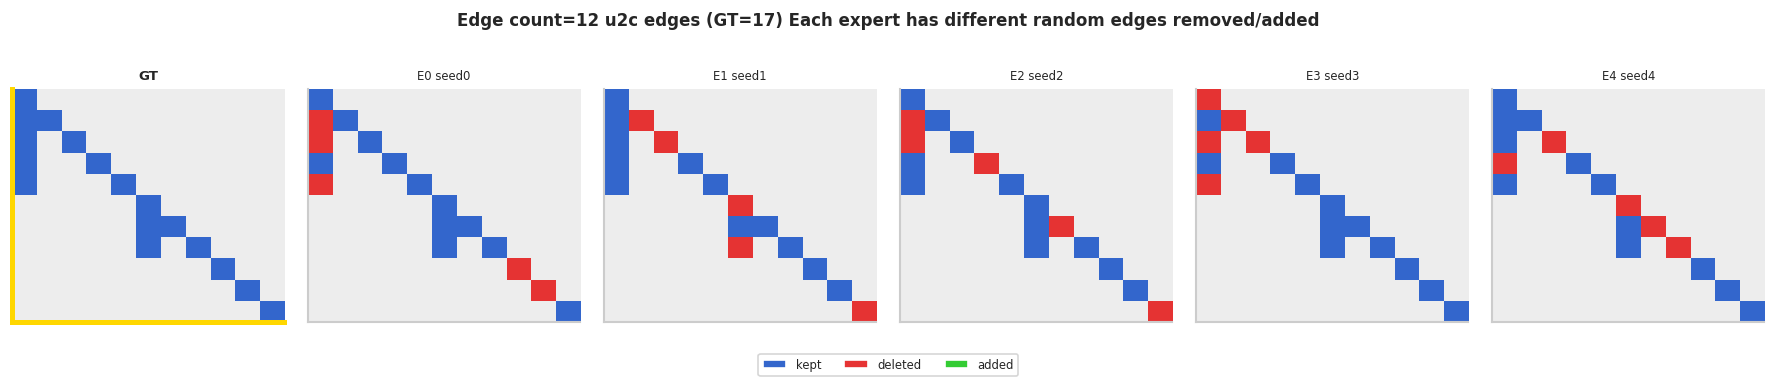

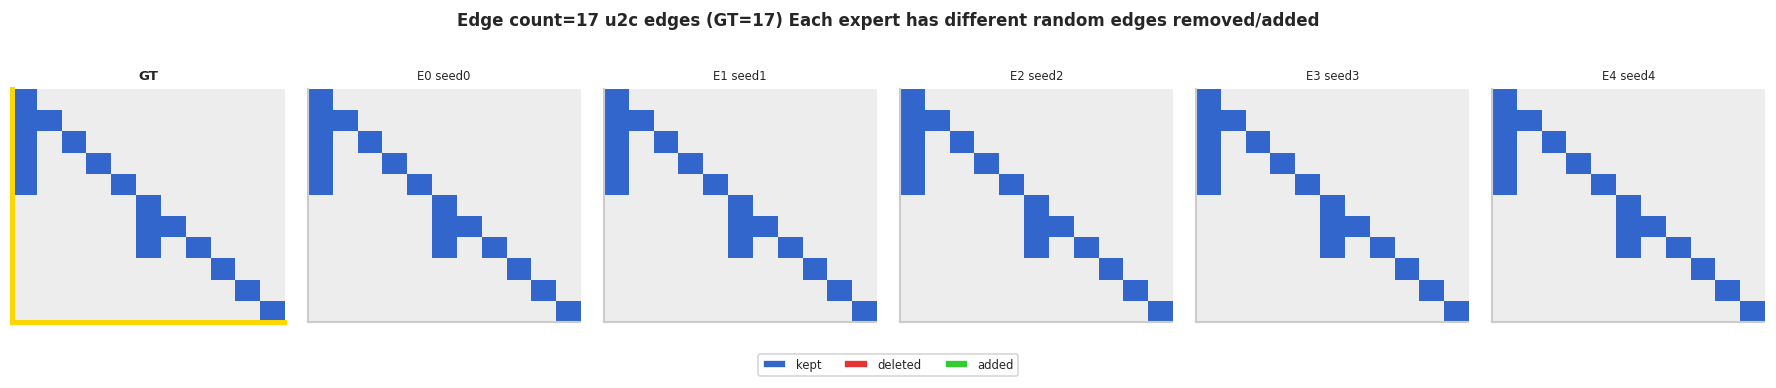

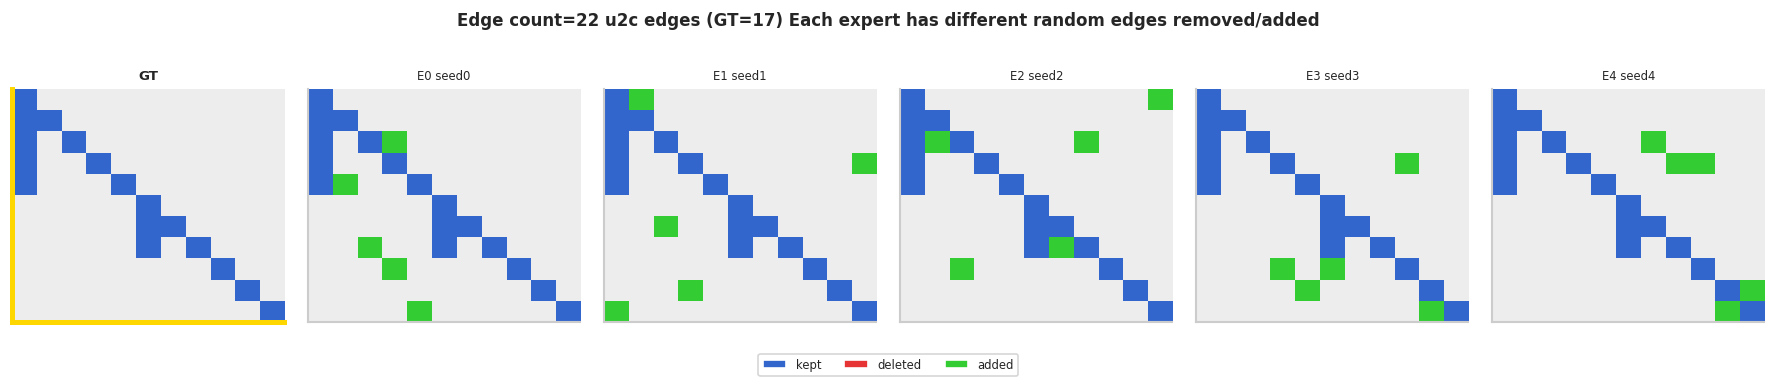

In [6]:
# Show expert graphs for a specific edge count
# Each expert has different random edges removed/added at the same total count
edge_counts_to_show = [12, 17, 22]  # GT-5, GT, GT+5
graphs_base = GRAPHS_ROOT / 'expert_graphs' / 'graph_ensemble_edge_count'

for count in edge_counts_to_show:
    d = graphs_base / f'u2c_{count}edges'
    if not d.exists(): print(f'Graphs not found: {d}'); continue
    dirs_and_indices = [(d, m, f'E{m} seed{m}') for m in range(N_EXPERTS)]
    show_expert_dags(dirs_and_indices, f'Edge count={count} u2c edges (GT=17) Each expert has different random edges removed/added')


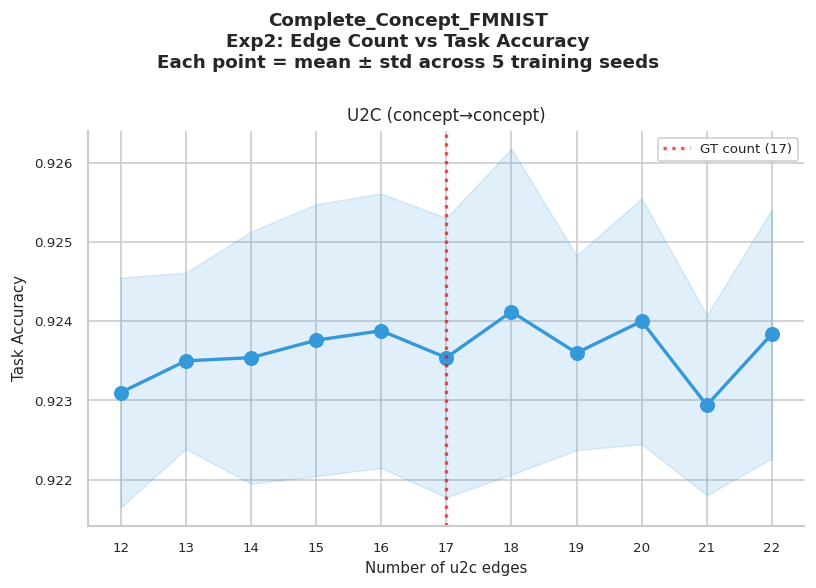

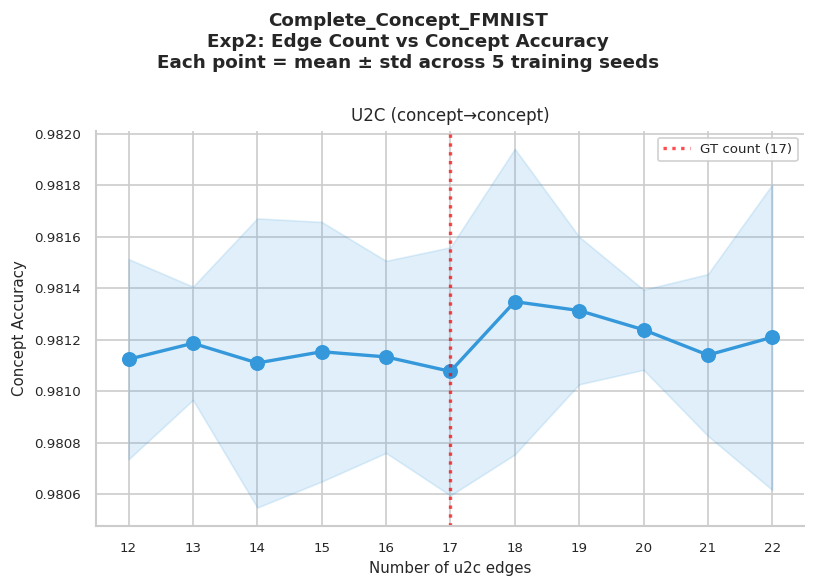

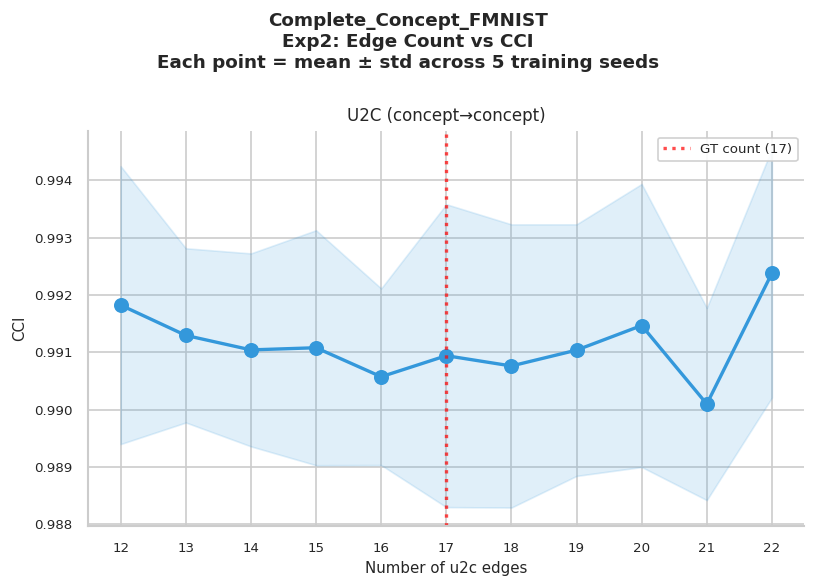

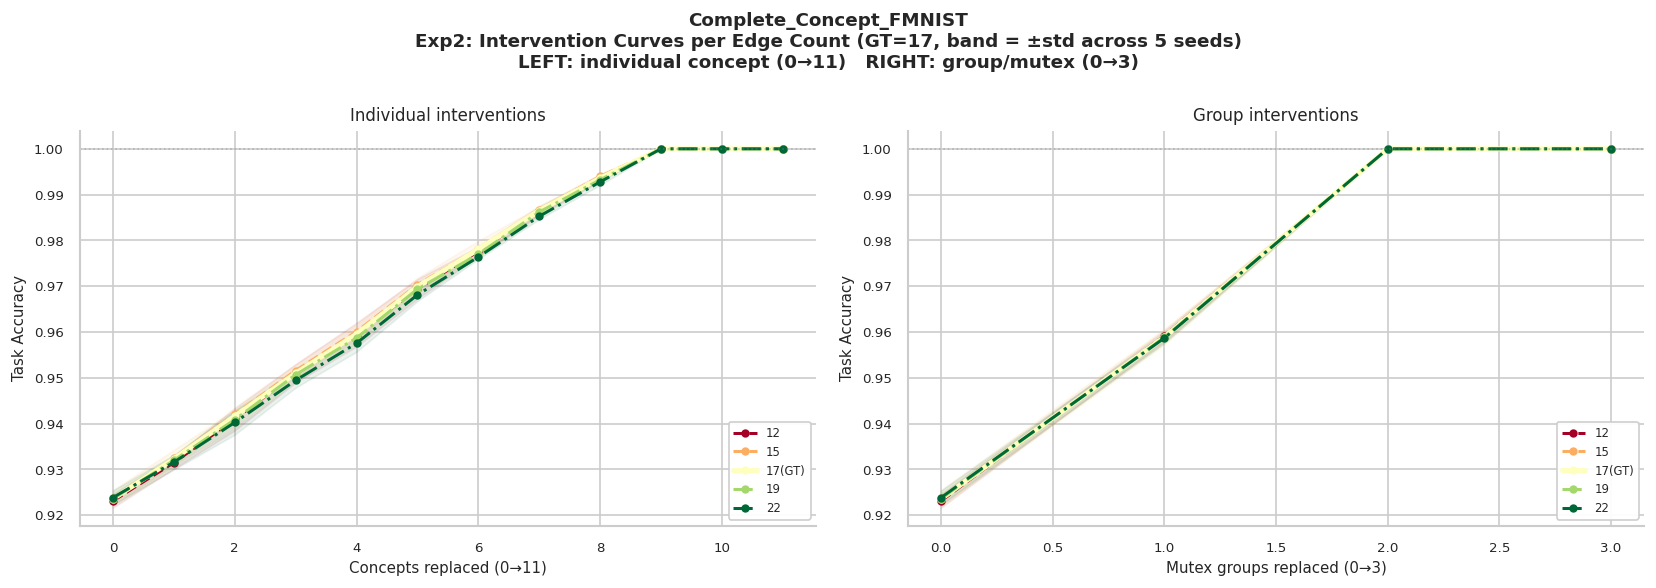

In [7]:
if len(exp2_df)==0:
    print('No Exp2 data yet.')
    print('Submit: bash server_scripts/mcream_experiment/submit_graph_ensemble_edge_count.sh --u2c-only')
else:
    GT_COUNT = 17
    TYPE_COLOR = {'u2c':'#3498db','c2y':'#e74c3c'}

    for metric, ylabel in [('test_task_accuracy','Task Accuracy'),
                            ('test_concept_accuracy','Concept Accuracy'),
                            ('CCI','CCI')]:
        if metric not in exp2_df.columns: continue
        for ds in DATASETS:
            ds_df=exp2_df[exp2_df['dataset']==ds].dropna(subset=[metric])
            if ds_df.empty: continue
            graph_types=sorted(ds_df['graph_type'].unique())
            fig,axes=plt.subplots(1,len(graph_types),figsize=(7*len(graph_types),5),sharey=False)
            if len(graph_types)==1: axes=[axes]
            fig.suptitle(f'{ds}\nExp2: Edge Count vs {ylabel}\n'
                         f'Each point = mean ± std across 5 training seeds',
                         fontsize=11,fontweight='bold')
            for ax,gtype in zip(axes,graph_types):
                sub=ds_df[ds_df['graph_type']==gtype]
                edge_counts=sorted(sub['edge_count'].unique())
                color=TYPE_COLOR.get(gtype,'#3498db')
                agg=sub.groupby('edge_count')[metric].agg(['mean','std']).reset_index()
                ax.plot(agg['edge_count'],agg['mean'],color=color,marker='o',markersize=8,lw=2)
                ax.fill_between(agg['edge_count'],agg['mean']-agg['std'],agg['mean']+agg['std'],alpha=0.15,color=color)
                ax.axvline(x=GT_COUNT,color='red',ls=':',lw=2,alpha=0.7,label=f'GT count ({GT_COUNT})')
                if len(gt_df)>0 and metric in gt_df.columns:
                    sub2=gt_df[gt_df['dataset']==ds]
                    if not sub2.empty and pd.notna(sub2[metric].mean()):
                        v=sub2[metric].mean()
                        ax.axhline(v,color='black',lw=2,ls='--',label=f'GT CREAM: {v:.4f}')
                ax.set_title(f'{gtype.upper()} ({"concept→concept" if gtype=="u2c" else "concept→task"})',fontsize=10)
                ax.set_xlabel('Number of u2c edges',fontsize=9)
                ax.set_ylabel(ylabel,fontsize=9)
                ax.set_xticks(edge_counts); ax.tick_params(labelsize=8)
                ax.legend(fontsize=8,framealpha=0.9)
            plt.tight_layout()
            plt.savefig(f'exp2_edge_count_{metric}_{ds}.png',dpi=150,bbox_inches='tight')
            plt.show()

    # ── Intervention curves: individual and group shown separately ─────────────
    exp2_interv = load_interventions(EXPERIMENTS_ROOT, exp_name_filter=['gensemble_edge_count_u2c'])

    if len(exp2_interv) > 0:
        import re
        exp2_interv['edge_count'] = exp2_interv['exp_name'].apply(
            lambda x: int(re.search(r'(\d+)edges', x).group(1))
            if re.search(r'(\d+)edges', x) else None)
        exp2_interv = exp2_interv.dropna(subset=['edge_count'])
        exp2_interv['edge_count'] = exp2_interv['edge_count'].astype(int)

        has_group_col = 'group_interventions' in exp2_interv.columns
        sub_indiv = exp2_interv[exp2_interv['group_interventions']==False] if has_group_col else exp2_interv
        sub_group = exp2_interv[exp2_interv['group_interventions']==True]  if has_group_col else pd.DataFrame()

        cmap = plt.cm.RdYlGn
        for ds in DATASETS:
            show_counts = [c for c in [12, 15, 17, 19, 22] if c in sub_indiv['edge_count'].unique()]
            if not show_counts: show_counts = sorted(sub_indiv['edge_count'].unique())
            all_counts = sorted(sub_indiv['edge_count'].unique())

            fig, axes = plt.subplots(1, 2, figsize=(14, 5))
            fig.suptitle(
                f'{ds}\nExp2: Intervention Curves per Edge Count (GT=17, band = ±std across 5 seeds)\n'
                f'LEFT: individual concept (0→11)   RIGHT: group/mutex (0→3)',
                fontsize=11, fontweight='bold'
            )

            for ax, src, xlabel, title_suffix in [
                (axes[0], sub_indiv, 'Concepts replaced (0→11)',  'Individual interventions'),
                (axes[1], sub_group, 'Mutex groups replaced (0→3)', 'Group interventions'),
            ]:
                ds_src = src[src['dataset']==ds] if 'dataset' in src.columns else src
                if ds_src.empty:
                    ax.set_title(f'{title_suffix} — no data'); ax.axis('off'); continue
                sc = [c for c in show_counts if c in ds_src['edge_count'].unique()]
                for count in sc:
                    lv  = ds_src[ds_src['edge_count']==count]
                    agg = lv.groupby('num_interventions')['test_task_accuracy'].agg(['mean','std']).reset_index()
                    norm  = all_counts.index(count) / max(len(all_counts)-1, 1)
                    color = cmap(norm)
                    style = '--' if count < GT_COUNT else ('-' if count==GT_COUNT else '-.')
                    lw    = 3 if count==GT_COUNT else 1.8
                    ax.plot(agg['num_interventions'], agg['mean'],
                            color=color, lw=lw, ls=style, marker='o', markersize=4,
                            label=f'{count}{"(GT)" if count==GT_COUNT else ""}')
                    ax.fill_between(agg['num_interventions'],
                                    agg['mean']-agg['std'], agg['mean']+agg['std'],
                                    alpha=0.08, color=color)
                ax.axhline(1.0, color='gray', ls=':', alpha=0.4, lw=1)
                ax.set_title(title_suffix, fontsize=10)
                ax.set_xlabel(xlabel, fontsize=9)
                ax.set_ylabel('Task Accuracy', fontsize=9)
                ax.legend(fontsize=7, loc='lower right', framealpha=0.95)
                ax.tick_params(labelsize=8)

            plt.tight_layout()
            plt.savefig(f'exp2_interventions_{ds}.png', dpi=150, bbox_inches='tight')
            plt.show()
    else:
        print('No intervention results for Exp2 yet.')

---
# Experiment 3 — Mixed Noise Levels

Experts from different noise levels (low/medium/high) in ONE model.
λ_m should learn: high-noise experts get higher weight (harder to train).


In [ ]:
def load_mixed_level_results(root):
    """Load Exp3: mixed noise levels.
    Folder names: graph_ensemble_mixed_deletion, graph_ensemble_mixed_addition, etc.
    """
    rows=[]
    for ds in DATASETS:
        ens_dir=root/ds/'train_cbm'/'mCREAM_GraphEnsemble'
        if not ens_dir.exists(): continue
        for exp_dir in sorted(ens_dir.iterdir()):
            if not exp_dir.is_dir(): continue
            name=exp_dir.name
            if 'mixed' not in name or not name.startswith('graph_ensemble_mixed'): continue
            # Extract action: graph_ensemble_mixed_{action}
            action=name.replace('graph_ensemble_mixed_','')
            for seed_dir in sorted(exp_dir.glob('seed_*/lightning_logs/version_*')):
                seed=int(seed_dir.parent.parent.name.split('_')[1])
                for csv_f in sorted(seed_dir.glob('*.csv')):
                    if any(x in csv_f.name for x in ['perc_','_set_','intervention','exogenous']): continue
                    try:
                        df=pd.read_csv(csv_f)
                        df['dataset']=ds;df['action']=action;df['seed']=seed
                        rows.append(df)
                    except: pass
    if not rows: print('No Exp3 data yet'); return pd.DataFrame()
    df=pd.concat(rows,ignore_index=True)
    print(f'Exp3 loaded: {len(df)} rows | actions={sorted(df.action.unique())}')
    return df

exp3_df     = load_mixed_level_results(EXPERIMENTS_ROOT)
exp3_interv = load_interventions(EXPERIMENTS_ROOT, exp_name_filter=['graph_ensemble_mixed'])


In [ ]:
# Show which expert graphs are used in mixed experiment
graphs_base = GRAPHS_ROOT / 'expert_graphs' / 'ensemble'
for action in ACTIONS:
    # Mixed assignment: low/0, medium/0, high/0, low/1, high/1
    dirs_and_indices = [
        (graphs_base/f'{action}_low',    0, f'E0\nlow'),
        (graphs_base/f'{action}_medium', 0, f'E1\nmedium'),
        (graphs_base/f'{action}_high',   0, f'E2\nhigh'),
        (graphs_base/f'{action}_low',    1, f'E3\nlow'),
        (graphs_base/f'{action}_high',   1, f'E4\nhigh'),
    ]
    show_expert_dags(dirs_and_indices, f'Exp3 mixed {action}: expert graphs (different noise levels)')


In [ ]:
if len(exp3_df)==0: print('No Exp3 data yet. Submit: bash submit_graph_ensemble.sh then run mixed configs')
else:
    KEY=['test_task_accuracy','test_concept_accuracy','CCI']
    av=[c for c in KEY if c in exp3_df.columns]
    print('--- Experiment 3: Mixed Noise Levels ---')
    display(exp3_df.groupby('action')[av].mean().round(4))
    # Lambda weights — the key result for Exp3
    lambda_cols=[c for c in exp3_df.columns if c.startswith('lambda_')]
    if lambda_cols:
        print('\nLearned lambda weights per expert (0=low noise, 2=high noise):')
        lam=exp3_df.groupby('action')[lambda_cols].mean().round(4)
        lam.columns=[f'E{c.replace("lambda_","")}' for c in lam.columns]
        display(lam)
        # Bar chart of lambdas
        fig,axes=plt.subplots(1,len(exp3_df['action'].unique()),figsize=(5*len(exp3_df['action'].unique()),4))
        if not hasattr(axes,'__len__'): axes=[axes]
        expert_labels=['E0\n(low)','E1\n(med)','E2\n(high)','E3\n(low)','E4\n(high)']
        for ax,action in zip(axes,sorted(exp3_df['action'].unique())):
            sub=exp3_df[exp3_df['action']==action][lambda_cols].mean()
            colors=['#3498db','#e67e22','#e74c3c','#3498db','#e74c3c']
            ax.bar(range(len(sub)),sub.values,color=colors,alpha=0.8)
            ax.axhline(0.2,color='black',ls='--',lw=1.5,alpha=0.5,label='uniform (0.2)')
            ax.set_xticks(range(len(sub))); ax.set_xticklabels(expert_labels,fontsize=8)
            ax.set_title(action,fontsize=10); ax.set_ylabel('Lambda weight')
            ax.legend(fontsize=7)
        fig.suptitle('Exp3: Learned lambda per expert\n(blue=low noise, red=high noise)',fontsize=11,fontweight='bold')
        plt.tight_layout(); plt.savefig('exp3_lambdas.png',dpi=150,bbox_inches='tight'); plt.show()
    # Intervention curves
    if len(exp3_interv)>0:
        fig,axes=plt.subplots(1,len(ACTIONS),figsize=(5*len(ACTIONS),4.5),sharey=True)
        fig.suptitle('Exp3: Mixed levels — intervention curves',fontsize=11,fontweight='bold')
        for ax,action in zip(axes,ACTIONS):
            sub=exp3_interv[exp3_interv['exp_name'].str.contains(f'mixed_{action}')]
            if sub.empty: ax.set_title(action); continue
            agg=sub.groupby('num_interventions')['test_task_accuracy'].agg(['mean','std']).reset_index()
            ax.plot(agg['num_interventions'],agg['mean'],color=ACTION_COLOR[action],lw=2.5,marker='o',markersize=5)
            ax.fill_between(agg['num_interventions'],agg['mean']-agg['std'],agg['mean']+agg['std'],alpha=0.15,color=ACTION_COLOR[action])
            ax.set_title(action,fontsize=10); ax.set_xlabel('Interventions'); ax.tick_params(labelsize=8)
            ax.set_ylabel('Task Accuracy' if action==ACTIONS[0] else '')
        plt.tight_layout(); plt.savefig('exp3_interventions.png',dpi=150,bbox_inches='tight'); plt.show()


---
# Alpha Matrix Analysis (use_alpha=True experiments only)

`alpha_prob[i,j]` = learned importance of edge concept_i → concept_j.

- **High value (near 1)** → edge is important for task/concept accuracy
- **Low value (near 0)** → edge was suppressed by L1 regularization
- Only edges present in the expert graph can have nonzero alpha (structural zeros enforced)

Saved per seed as `alpha_prob_seed{N}.csv` inside `lightning_logs/version_0/`.

---
# Experiment 4 — Consensus Experts + Shared Alpha Matrix

M=5 experts with 90% pairwise consensus (shared base noise + 5% private flips).
Shared learnable α[K,K] matrix gates edge importance across all experts.

**Three noise levels (updated):**
- `low`    → base corruption 15% of GT edges
- `medium` → base corruption 25%
- `high`   → base corruption 50%

**What to look for:**
- Does α converge to high values on GT edges (diagonal) and low on corrupted edges?
- Does higher base noise → lower task accuracy / higher alpha sparsity?
- Compare intervention curves vs Exp1 (single-action noise, no alpha)

**Datasets:** cfmnist + CelebA

Loaded alpha for 6 experiments
  Complete_Concept_FMNIST/graph_ensemble_consensus_high: 5 seeds
  Complete_Concept_FMNIST/graph_ensemble_consensus_low: 5 seeds
  Complete_Concept_FMNIST/graph_ensemble_consensus_medium: 5 seeds
  CelebA/graph_ensemble_consensus_high: 5 seeds
  CelebA/graph_ensemble_consensus_low: 5 seeds
  CelebA/graph_ensemble_consensus_medium: 5 seeds


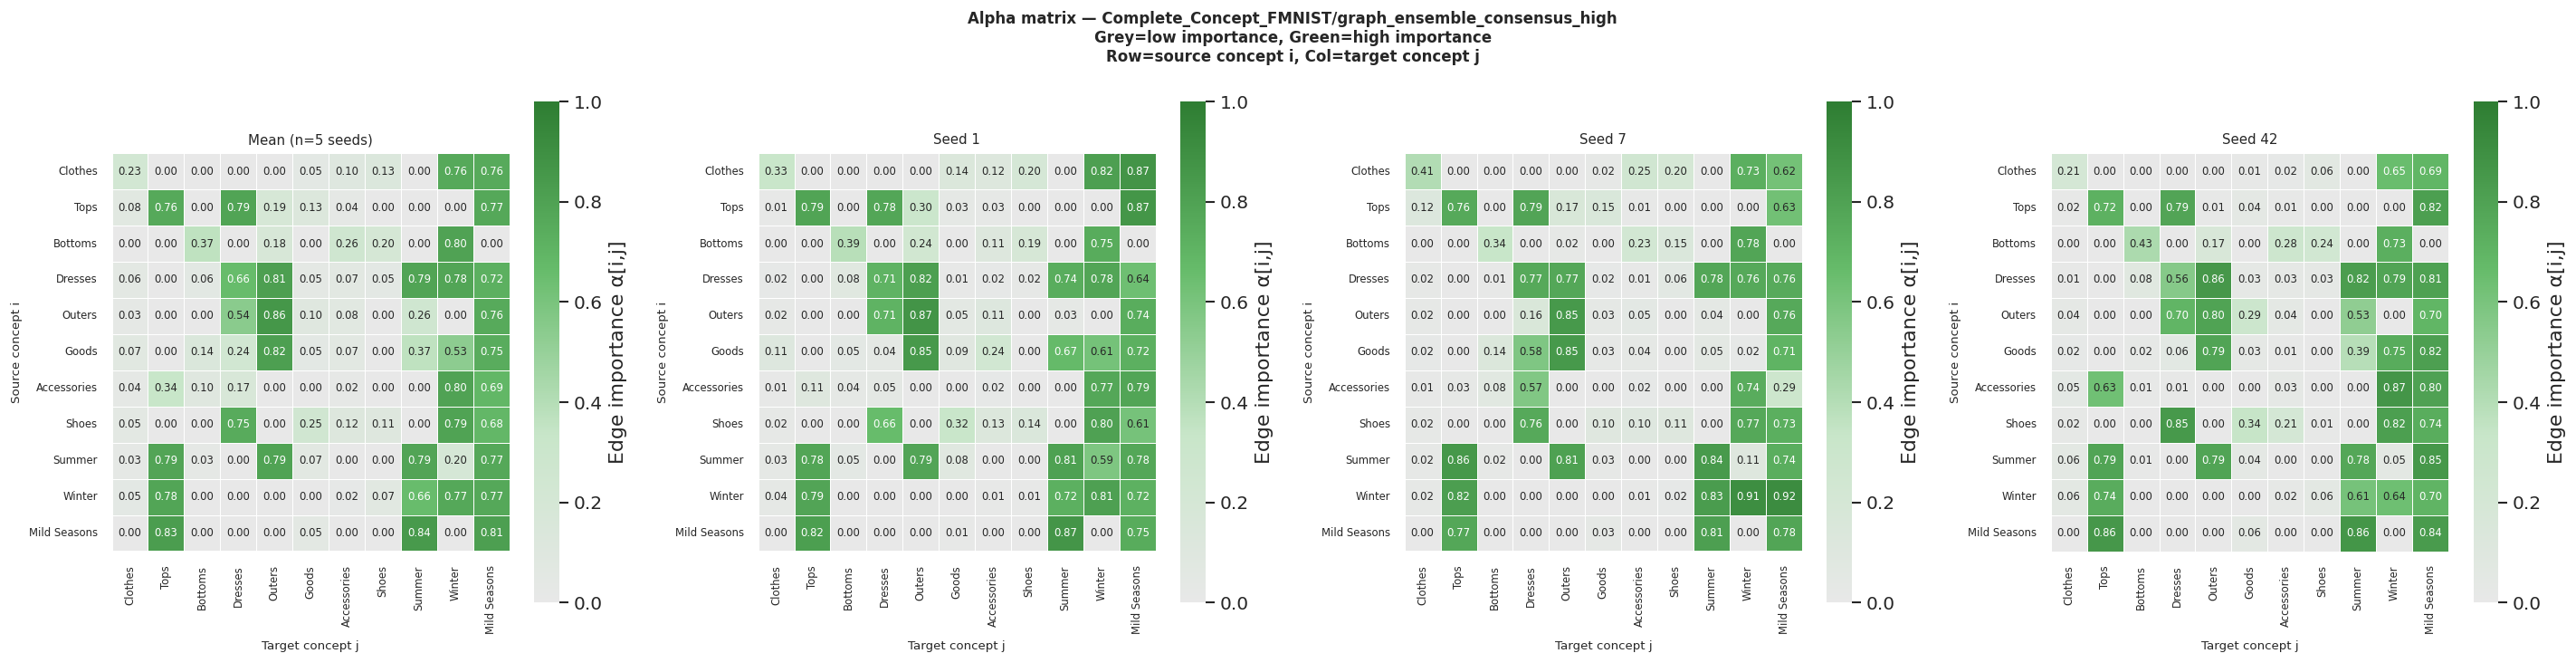


--- Complete_Concept_FMNIST/graph_ensemble_consensus_high: Top 5 most important edges (mean α) ---
  Outers → Outers: α=0.861 ± 0.038
  Mild Seasons → Summer: α=0.842 ± 0.023
  Mild Seasons → Tops: α=0.828 ± 0.033
  Goods → Outers: α=0.816 ± 0.029
  Mild Seasons → Mild Seasons: α=0.813 ± 0.043
--- Bottom 5 ---
  Tops → Bottoms: α=0.004
  Goods → Tops: α=0.004
  Summer → Accessories: α=0.004
  Accessories → Outers: α=0.004
  Shoes → Outers: α=0.004


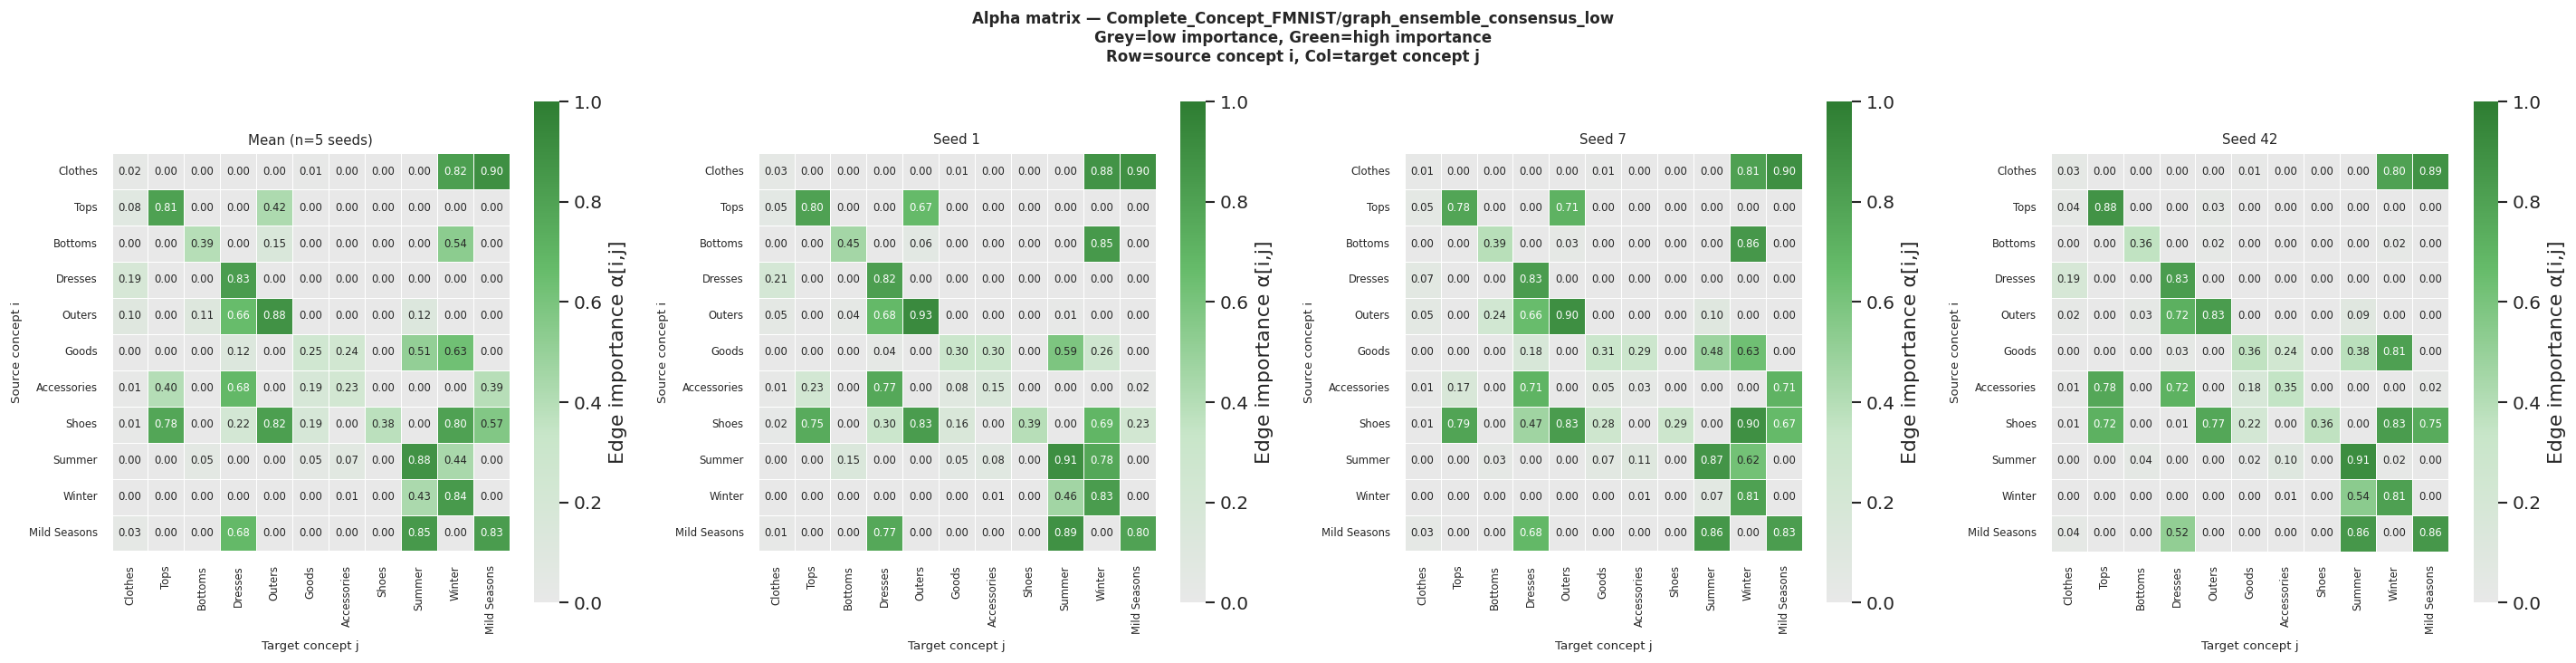


--- Complete_Concept_FMNIST/graph_ensemble_consensus_low: Top 5 most important edges (mean α) ---
  Clothes → Mild Seasons: α=0.903 ± 0.027
  Outers → Outers: α=0.884 ± 0.033
  Summer → Summer: α=0.883 ± 0.024
  Mild Seasons → Summer: α=0.849 ± 0.031
  Winter → Winter: α=0.843 ± 0.034
--- Bottom 5 ---
  Goods → Outers: α=0.004
  Goods → Bottoms: α=0.004
  Goods → Tops: α=0.004
  Goods → Clothes: α=0.004
  Accessories → Summer: α=0.004


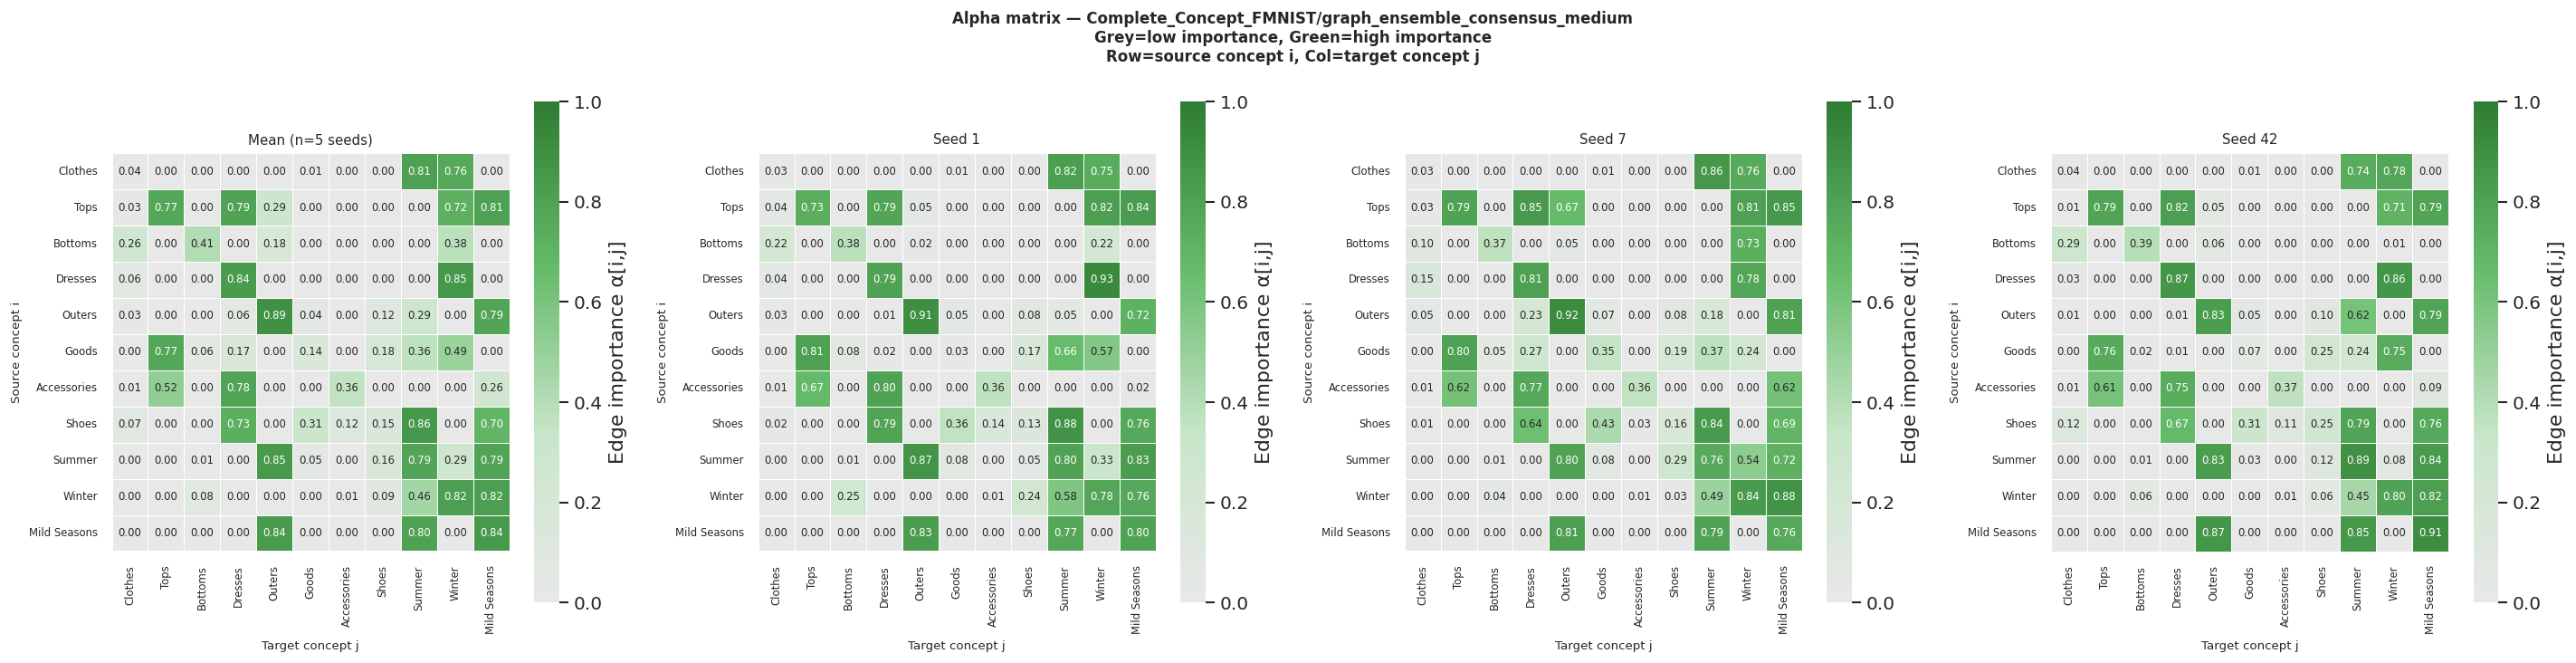


--- Complete_Concept_FMNIST/graph_ensemble_consensus_medium: Top 5 most important edges (mean α) ---
  Outers → Outers: α=0.889 ± 0.032
  Shoes → Summer: α=0.855 ± 0.038
  Dresses → Winter: α=0.853 ± 0.052
  Summer → Outers: α=0.845 ± 0.028
  Mild Seasons → Mild Seasons: α=0.844 ± 0.058
--- Bottom 5 ---
  Shoes → Bottoms: α=0.004
  Bottoms → Dresses: α=0.004
  Dresses → Mild Seasons: α=0.004
  Bottoms → Tops: α=0.004
  Shoes → Outers: α=0.004


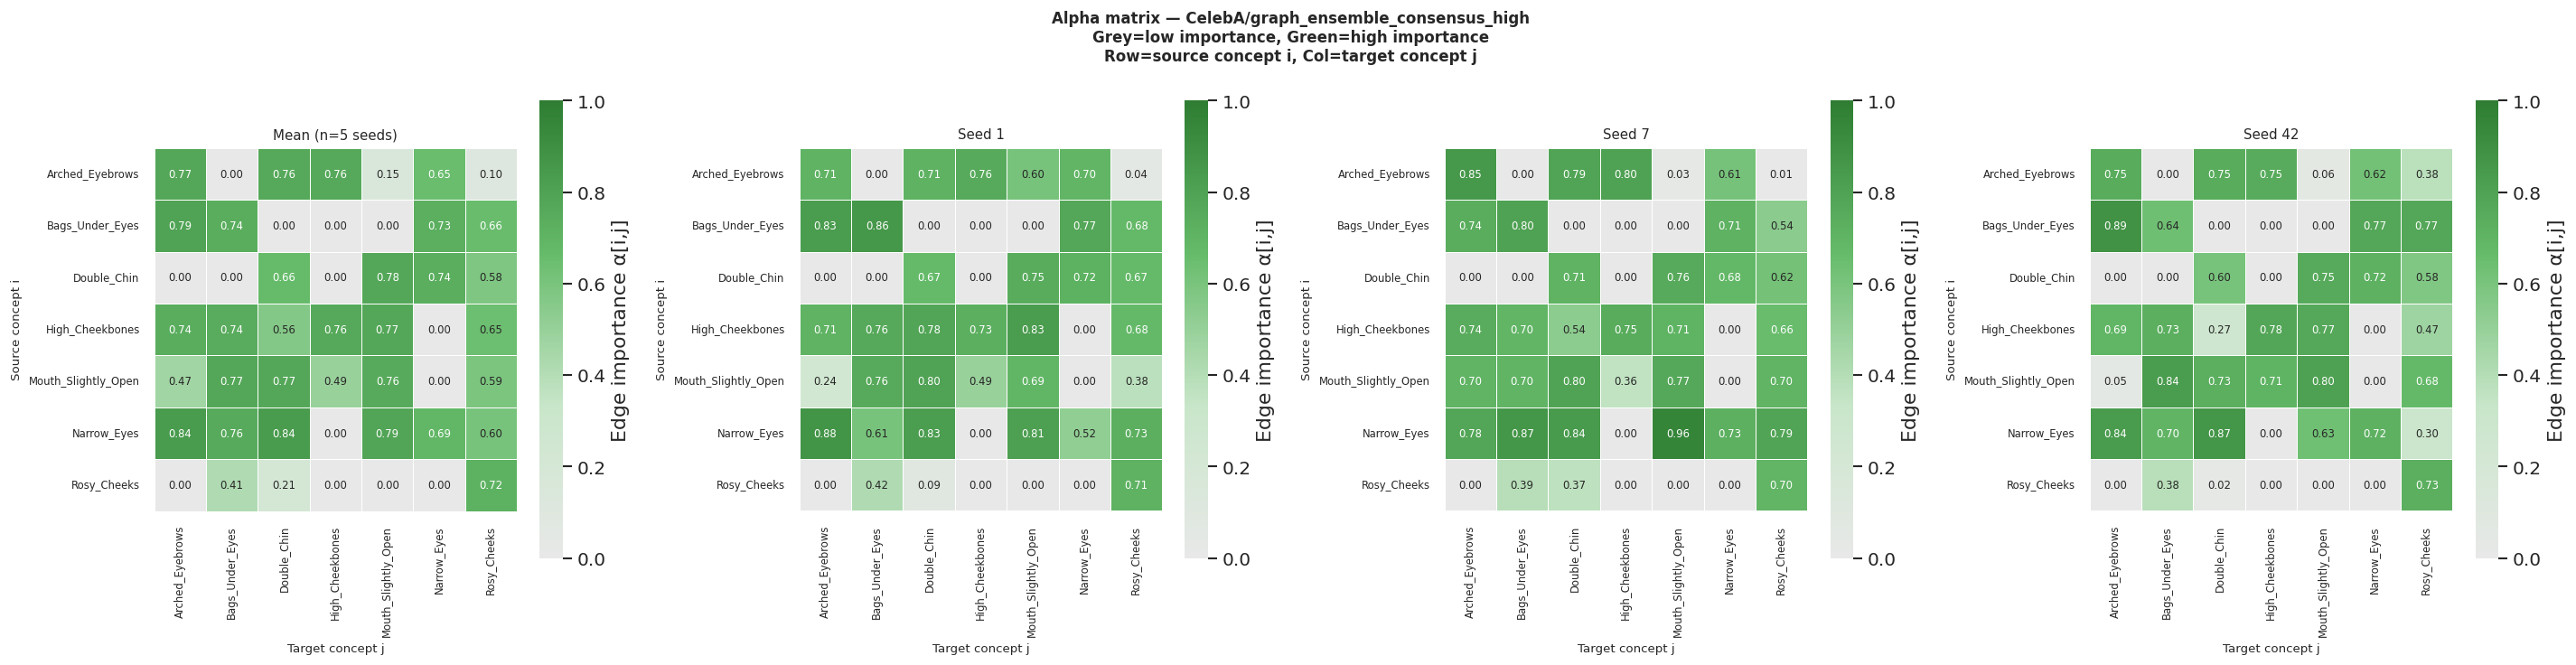


--- CelebA/graph_ensemble_consensus_high: Top 5 most important edges (mean α) ---
  Narrow_Eyes → Arched_Eyebrows: α=0.839 ± 0.039
  Narrow_Eyes → Double_Chin: α=0.836 ± 0.017
  Bags_Under_Eyes → Arched_Eyebrows: α=0.794 ± 0.057
  Narrow_Eyes → Mouth_Slightly_Open: α=0.789 ± 0.104
  Double_Chin → Mouth_Slightly_Open: α=0.776 ± 0.054
--- Bottom 5 ---
  Mouth_Slightly_Open → Narrow_Eyes: α=0.002
  Double_Chin → Bags_Under_Eyes: α=0.002
  Bags_Under_Eyes → High_Cheekbones: α=0.002
  Bags_Under_Eyes → Double_Chin: α=0.002
  Bags_Under_Eyes → Mouth_Slightly_Open: α=0.002


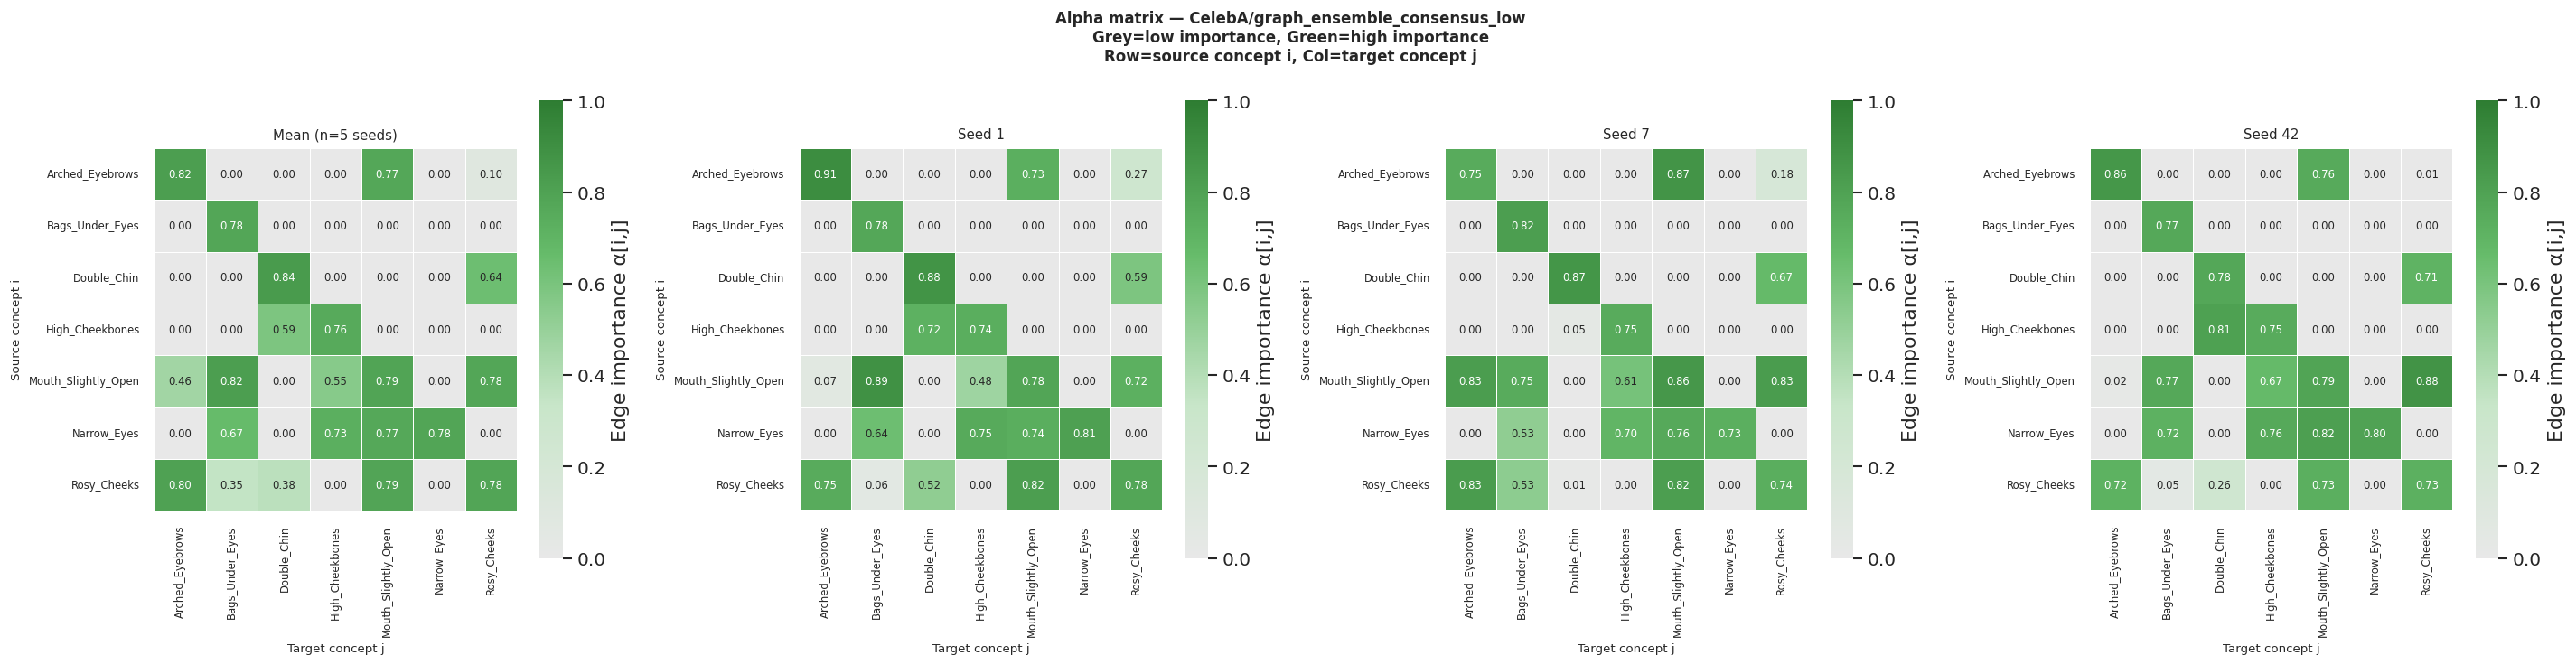


--- CelebA/graph_ensemble_consensus_low: Top 5 most important edges (mean α) ---
  Double_Chin → Double_Chin: α=0.838 ± 0.038
  Arched_Eyebrows → Arched_Eyebrows: α=0.821 ± 0.059
  Mouth_Slightly_Open → Bags_Under_Eyes: α=0.820 ± 0.063
  Rosy_Cheeks → Arched_Eyebrows: α=0.802 ± 0.061
  Mouth_Slightly_Open → Mouth_Slightly_Open: α=0.791 ± 0.048
--- Bottom 5 ---
  Arched_Eyebrows → Bags_Under_Eyes: α=0.002
  Double_Chin → High_Cheekbones: α=0.002
  High_Cheekbones → Bags_Under_Eyes: α=0.002
  High_Cheekbones → Arched_Eyebrows: α=0.002
  Bags_Under_Eyes → Rosy_Cheeks: α=0.002


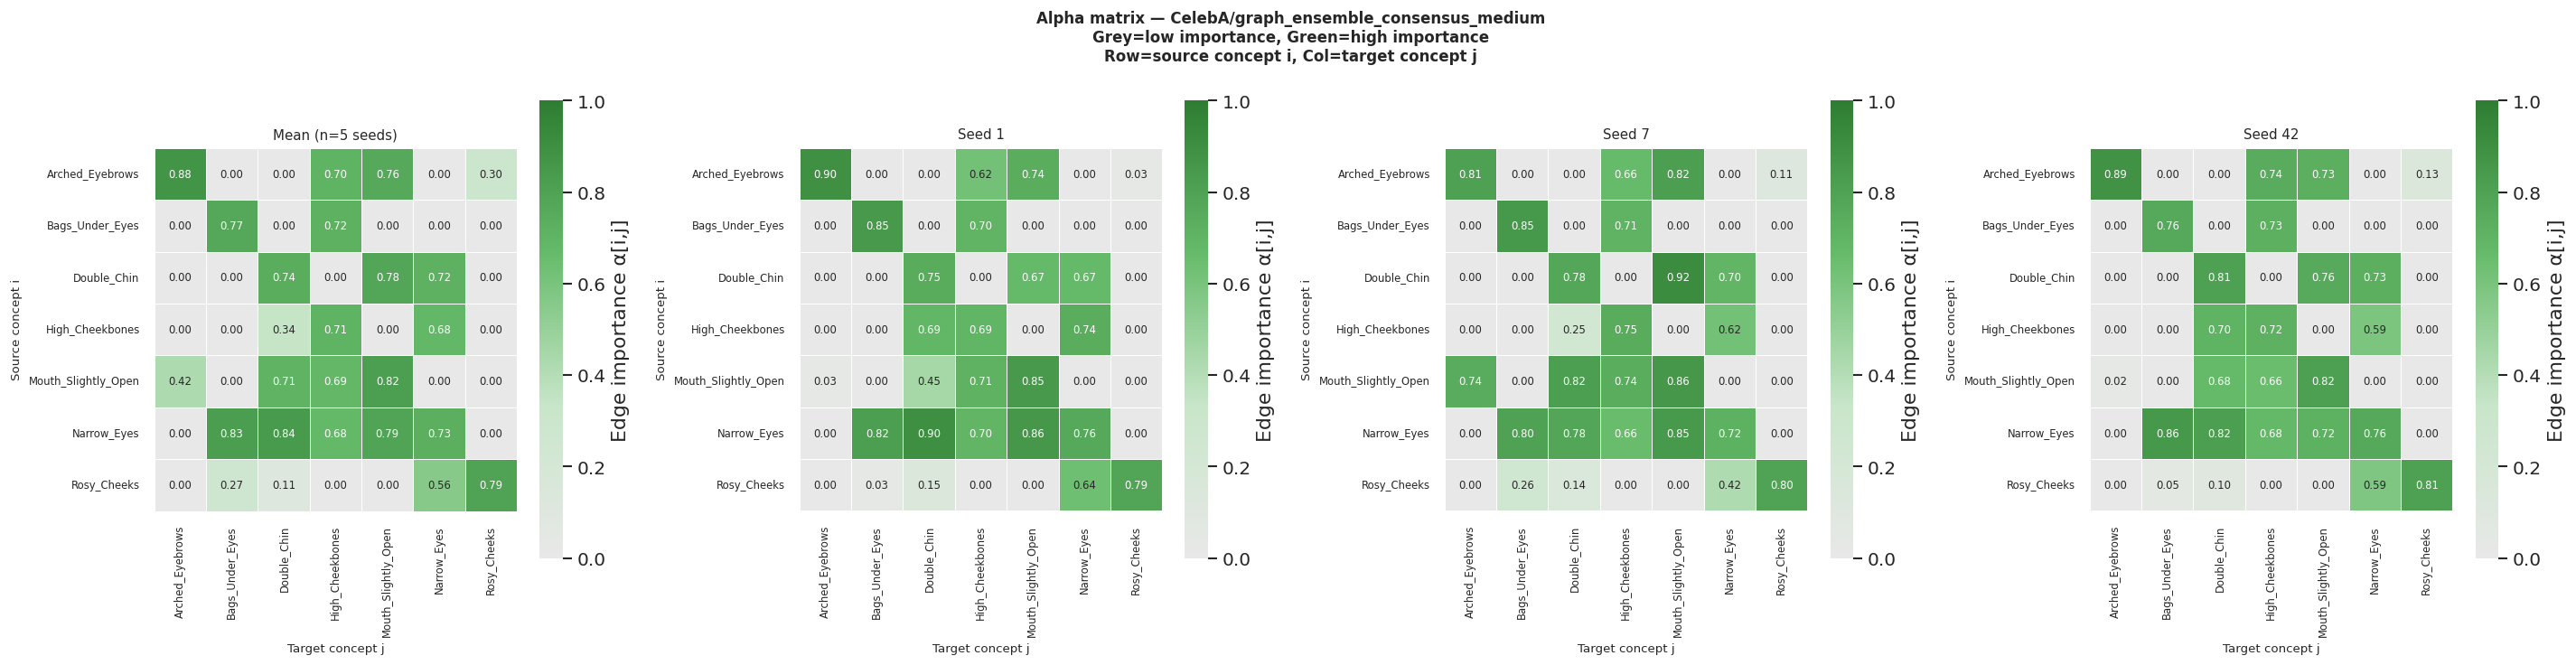


--- CelebA/graph_ensemble_consensus_medium: Top 5 most important edges (mean α) ---
  Arched_Eyebrows → Arched_Eyebrows: α=0.876 ± 0.034
  Narrow_Eyes → Double_Chin: α=0.841 ± 0.040
  Narrow_Eyes → Bags_Under_Eyes: α=0.826 ± 0.017
  Mouth_Slightly_Open → Mouth_Slightly_Open: α=0.824 ± 0.024
  Rosy_Cheeks → Rosy_Cheeks: α=0.794 ± 0.011
--- Bottom 5 ---
  Bags_Under_Eyes → Narrow_Eyes: α=0.002
  Bags_Under_Eyes → Mouth_Slightly_Open: α=0.002
  Bags_Under_Eyes → Double_Chin: α=0.002
  Bags_Under_Eyes → Arched_Eyebrows: α=0.002
  High_Cheekbones → Rosy_Cheeks: α=0.002


In [3]:
def load_alpha_matrices(root, exp_name_filter=None):
    """Load alpha_prob_seed*.csv for all seeds of matching experiments — both datasets."""
    result = {}
    search_datasets = ['Complete_Concept_FMNIST', 'CelebA']
    for ds in search_datasets:
        ens_dir = root / ds / 'train_cbm' / 'mCREAM_GraphEnsemble'
        if not ens_dir.exists(): continue
        for exp_dir in sorted(ens_dir.iterdir()):
            if not exp_dir.is_dir(): continue
            name = exp_dir.name
            if exp_name_filter and not any(f in name for f in exp_name_filter): continue
            seed_alphas = {}
            for seed_dir in sorted(exp_dir.glob('seed_*/lightning_logs/version_*')):
                seed = int(seed_dir.parent.parent.name.split('_')[1])
                for alpha_f in sorted(seed_dir.glob('alpha_prob_seed*.csv')):
                    try:
                        df = pd.read_csv(alpha_f, index_col=0)
                        seed_alphas[seed] = df
                    except: pass
            if seed_alphas:
                key = f'{ds}/{name}'
                result[key] = seed_alphas
    if not result:
        print('No alpha matrices found. Run with use_alpha=True in config.')
    else:
        print(f'Loaded alpha for {len(result)} experiments')
        for k, v in result.items():
            print(f'  {k}: {len(v)} seeds')
    return result


def plot_alpha(alpha_df, title, ax=None, vmin=0, vmax=1):
    """Plot alpha [K,K] heatmap — grey=low importance, green=high importance."""
    standalone = ax is None
    if standalone:
        fig, ax = plt.subplots(figsize=(7, 6))
    # Custom colormap: light grey (0) → dark green (1)
    from matplotlib.colors import LinearSegmentedColormap
    cmap_gg = LinearSegmentedColormap.from_list('grey_green',
        ['#e8e8e8', '#c8e6c9', '#66bb6a', '#2e7d32'])
    sns.heatmap(alpha_df, ax=ax, vmin=vmin, vmax=vmax, cmap=cmap_gg,
                annot=True, fmt='.2f', linewidths=0.5, square=True,
                annot_kws={'size': 7},
                cbar_kws={'label': 'Edge importance α[i,j]'})
    ax.set_title(title, fontsize=9)
    ax.set_xlabel('Target concept j', fontsize=8)
    ax.set_ylabel('Source concept i', fontsize=8)
    ax.tick_params(labelsize=7)
    if standalone:
        plt.tight_layout()
        plt.show()
    return ax


# ── Load alpha for all experiments ────────────────────────────────────────────
all_alpha = load_alpha_matrices(EXPERIMENTS_ROOT)

if all_alpha:
    for exp_key, seed_alphas in all_alpha.items():
        seeds = sorted(seed_alphas.keys())
        stacked = np.stack([seed_alphas[s].values for s in seeds], axis=0)
        mean_alpha = pd.DataFrame(stacked.mean(axis=0),
                                  index=seed_alphas[seeds[0]].index,
                                  columns=seed_alphas[seeds[0]].columns)
        std_alpha  = pd.DataFrame(stacked.std(axis=0),
                                  index=seed_alphas[seeds[0]].index,
                                  columns=seed_alphas[seeds[0]].columns)

        fig, axes = plt.subplots(1, min(len(seeds)+1, 4), figsize=(6*min(len(seeds)+1,4), 6))
        if not hasattr(axes, '__len__'): axes = [axes]
        fig.suptitle(f'Alpha matrix — {exp_key}\n'
                     f'Grey=low importance, Green=high importance\n'
                     f'Row=source concept i, Col=target concept j',
                     fontsize=10, fontweight='bold')
        plot_alpha(mean_alpha, f'Mean (n={len(seeds)} seeds)', axes[0])
        for ax, seed in zip(axes[1:], seeds[:3]):
            plot_alpha(seed_alphas[seed], f'Seed {seed}', ax)
        plt.tight_layout()
        safe = exp_key.replace('/', '_')
        plt.savefig(f'alpha_{safe}.png', dpi=150, bbox_inches='tight')
        plt.show()

        print(f'\n--- {exp_key}: Top 5 most important edges (mean α) ---')
        flat = mean_alpha.stack().sort_values(ascending=False)
        for (src, tgt), val in flat.head(5).items():
            print(f'  {src} → {tgt}: α={val:.3f} ± {std_alpha.loc[src,tgt]:.3f}')
        print(f'--- Bottom 5 ---')
        for (src, tgt), val in flat[flat > 0].tail(5).items():
            print(f'  {src} → {tgt}: α={val:.3f}')

In [ ]:
def load_consensus_results(root):
    """Load Exp4 results for cfmnist, CelebA, and CUB."""
    rows = []
    for ds in list(DATASET_CONFIG.keys()):
        ens_dir = root / ds / 'train_cbm' / 'mCREAM_GraphEnsemble'
        if not ens_dir.exists(): continue
        for exp_dir in sorted(ens_dir.iterdir()):
            name = exp_dir.name
            if not name.startswith('graph_ensemble_consensus_'): continue
            import re
            m = re.match(r'graph_ensemble_consensus_(low|medium|high)', name)
            if not m: continue
            level = m.group(1)
            for seed_dir in sorted(exp_dir.glob('seed_*/lightning_logs/version_*')):
                seed = int(seed_dir.parent.parent.name.split('_')[1])
                for csv_f in sorted(seed_dir.glob('*.csv')):
                    if any(x in csv_f.name for x in ['perc_','_set_','intervention','exogenous','alpha']): continue
                    try:
                        df = pd.read_csv(csv_f)
                        df['dataset'] = ds; df['noise_level'] = level; df['seed'] = seed
                        rows.append(df)
                    except: pass
    if not rows: print('No Exp4 consensus results yet.'); return pd.DataFrame()
    df = pd.concat(rows, ignore_index=True)
    print(f'Exp4 loaded: {len(df)} rows | datasets={sorted(df.dataset.unique())} | levels={sorted(df.noise_level.unique())}')
    return df

exp4_df     = load_consensus_results(EXPERIMENTS_ROOT)
exp4_interv = load_interventions(EXPERIMENTS_ROOT, exp_name_filter=['graph_ensemble_consensus'],
                                  datasets=list(DATASET_CONFIG.keys()))
exp4_alpha  = load_alpha_matrices(EXPERIMENTS_ROOT, exp_name_filter=['graph_ensemble_consensus'])

# ── Show expert graphs for each dataset × level ───────────────────────────────
for ds, dscfg in DATASET_CONFIG.items():
    graphs_base = dscfg['graphs_root'] / 'expert_graphs' / 'consensus'
    K           = dscfg['num_concepts']
    dag_path    = dscfg['dag']
    if not dag_path.exists(): continue

    for level in LEVELS:
        level_dir = graphs_base / level
        if not level_dir.exists(): print(f'Graphs not found: {level_dir}'); continue
        dirs_and_indices = [(level_dir, m, f'E{m}') for m in range(N_EXPERTS)]
        p_base = {"low": 0.15, "medium": 0.25, "high": 0.50}[level]
        show_expert_dags(
            dirs_and_indices,
            f'Exp4 consensus {ds} — {level} noise (p_base={p_base})\n'
            f'Blue=GT edge kept, Red=GT edge deleted, Green=edge added',
            K=K, dag_path=dag_path
        )

In [ ]:
if len(exp4_df) == 0:
    print('No Exp4 data yet.')
    print('Step 1: python generate_consensus_expert_graphs.py --dataset cfmnist --consensus 0.90')
    print('Step 2: bash server_scripts/mcream_experiment/submit_graph_ensemble_consensus.sh')
else:
    lnum = {'low': 0.15, 'medium': 0.25, 'high': 0.50}
    KEY  = ['test_task_accuracy', 'test_concept_accuracy', 'CCI', 'alpha_mean', 'alpha_sparsity']
    av   = [c for c in KEY if c in exp4_df.columns]

    # ── Summary table per dataset ──────────────────────────────────────────────
    for ds in sorted(exp4_df['dataset'].unique()):
        sub   = exp4_df[exp4_df['dataset']==ds]
        means = sub.groupby('noise_level')[av].mean()
        stds  = sub.groupby('noise_level')[av].std()
        sm    = pd.DataFrame({c: means[c].map('{:.4f}'.format)+' ± '+stds[c].map('{:.4f}'.format) for c in av})
        print(f'=== Exp4: {ds} — Consensus 90% + shared alpha ===')
        display(sm)

    # ── Accuracy vs noise level — one plot per dataset ────────────────────────
    datasets_exp4 = sorted(exp4_df['dataset'].unique())
    for metric, ylabel in [('test_task_accuracy','Task Accuracy'), ('test_concept_accuracy','Concept Accuracy')]:
        if metric not in exp4_df.columns: continue
        fig, axes = plt.subplots(1, len(datasets_exp4), figsize=(6*len(datasets_exp4), 4.5), sharey=False)
        if not hasattr(axes, '__len__'): axes = [axes]
        fig.suptitle(f'Exp4: Consensus 90% — {ylabel} vs base noise', fontsize=11, fontweight='bold')
        for ax, ds in zip(axes, datasets_exp4):
            d = exp4_df[exp4_df['dataset']==ds].copy()
            d['noise_prob'] = d['noise_level'].map(lnum)
            agg = d.groupby('noise_prob')[metric].agg(['mean','std']).reset_index()
            ax.plot(agg['noise_prob'], agg['mean'], color='#8e44ad', marker='o', markersize=8, lw=2)
            ax.fill_between(agg['noise_prob'], agg['mean']-agg['std'], agg['mean']+agg['std'], alpha=0.15, color='#8e44ad')
            if ds == 'Complete_Concept_FMNIST' and len(gt_df) > 0 and metric in gt_df.columns:
                v = gt_df[metric].mean()
                ax.axhline(v, color='black', lw=2, ls='--', label=f'GT CREAM: {v:.4f}')
            ax.set_title(ds.replace('Complete_Concept_',''), fontsize=10)
            ax.set_xlabel('Base noise probability')
            ax.set_ylabel(ylabel if ax is axes[0] else '')
            ax.set_xticks([0.15, 0.25, 0.50]); ax.set_xticklabels(['low\n(15%)', 'medium\n(25%)', 'high\n(50%)'])
            ax.legend(fontsize=8)
        plt.tight_layout(); plt.savefig(f'exp4_{metric}.png', dpi=150, bbox_inches='tight'); plt.show()

    # ── Intervention curves — per dataset ─────────────────────────────────────
    if len(exp4_interv) > 0:
        has_group = 'group_interventions' in exp4_interv.columns
        for ds in sorted(exp4_interv['dataset'].unique()):
            ds_iv     = exp4_interv[exp4_interv['dataset']==ds]
            sub_indiv = ds_iv[ds_iv['group_interventions']==False] if has_group else ds_iv
            sub_group = ds_iv[ds_iv['group_interventions']==True]  if has_group else pd.DataFrame()

            fig, axes = plt.subplots(1, 2, figsize=(14, 5))
            fig.suptitle(f'Exp4 {ds}: Consensus 90% — Intervention curves\n'
                         f'LEFT: individual   RIGHT: group/mutex',
                         fontsize=11, fontweight='bold')
            for ax, src, xlabel, title in [
                (axes[0], sub_indiv, 'Concepts replaced',   'Individual'),
                (axes[1], sub_group, 'Mutex groups replaced', 'Group'),
            ]:
                if src.empty: ax.set_title(f'{title} — no data'); ax.axis('off'); continue
                for level in LEVELS:
                    lv = src[src['exp_name'].str.contains(level)]
                    if lv.empty: continue
                    agg = lv.groupby('num_interventions')['test_task_accuracy'].agg(['mean','std']).reset_index()
                    col = LEVEL_COLOR[level]
                    ax.plot(agg['num_interventions'], agg['mean'], color=col, lw=2.5, marker='o', markersize=5, label=level)
                    ax.fill_between(agg['num_interventions'], agg['mean']-agg['std'], agg['mean']+agg['std'], alpha=0.15, color=col)
                ax.set_title(title); ax.set_xlabel(xlabel); ax.set_ylabel('Task Accuracy'); ax.legend(fontsize=9)
            plt.tight_layout()
            safe_ds = ds.replace(' ','_')
            plt.savefig(f'exp4_interventions_{safe_ds}.png', dpi=150, bbox_inches='tight'); plt.show()

    # ── Alpha heatmaps — per dataset × level ──────────────────────────────────
    if exp4_alpha:
        for exp_key, seed_alphas in exp4_alpha.items():
            seeds   = sorted(seed_alphas.keys())
            stacked = np.stack([seed_alphas[s].values for s in seeds], axis=0)
            mean_df = pd.DataFrame(stacked.mean(0), index=seed_alphas[seeds[0]].index,
                                   columns=seed_alphas[seeds[0]].columns)
            fig, ax = plt.subplots(figsize=(7, 6))
            fig.suptitle(f'Alpha — {exp_key}  (mean across {len(seeds)} seeds)\n'
                         f'Grey=low importance, Green=high importance',
                         fontsize=10, fontweight='bold')
            plot_alpha(mean_df, '', ax)
            plt.tight_layout()
            plt.savefig(f'alpha_{exp_key.replace("/","_")}.png', dpi=150, bbox_inches='tight'); plt.show()
            flat = mean_df.stack().sort_values(ascending=False)
            print(f'{exp_key} — top 5 important edges:')
            for (src, tgt), val in flat.head(5).items():
                print(f'  {src} → {tgt}: α={val:.3f}')

---
# Learning Curves — Training Loss per Epoch

Loads `metrics.csv` from each `seed_*/lightning_logs/version_*/` directory.
Shows `train_task_loss`, `train_concept_loss`, `train_total_loss` across epochs.

Useful for:
- Diagnosing convergence
- Explaining accuracy variance across seeds (do some seeds diverge early?)
- Showing supervisor that training is stable

In [22]:
import re as _re

def load_learning_curves(root, exp_name_filter=None):
    """Load per-epoch metrics.csv for all seeds of matching experiments."""
    rows = []
    for ds in DATASETS:
        ens_dir = root / ds / 'train_cbm' / 'mCREAM_GraphEnsemble'
        if not ens_dir.exists(): continue
        for exp_dir in sorted(ens_dir.iterdir()):
            if not exp_dir.is_dir(): continue
            name = exp_dir.name
            # print(name)
            if exp_name_filter and not any(f in name for f in exp_name_filter): continue
            for seed_dir in sorted(exp_dir.glob('seed_*/lightning_logs/version_*')):
                seed = int(seed_dir.parent.parent.name.split('_')[1])
                metrics_f = seed_dir / f'{name}.csv'
                print(metrics_f)
                if not metrics_f.exists(): continue
                try:
                    # print("in try")
                    df = pd.read_csv(metrics_f)
                    df['exp_name'] = name; df['seed'] = seed; df['dataset'] = ds
                    rows.append(df)
                    # print(len(rows))
                except: pass
    print(len(rows))
    if not rows: print('No metrics.csv found.'); return pd.DataFrame()
    df = pd.concat(rows, ignore_index=True)
    print(f'Learning curves: {len(df)} epoch rows | exps={df.exp_name.nunique()} | seeds={sorted(df.seed.unique())}')
    return df

lc_exp1 = load_learning_curves(EXPERIMENTS_ROOT,
    exp_name_filter=['graph_ensemble_deletion','graph_ensemble_addition','graph_ensemble_reversal'])
lc_exp2 = load_learning_curves(EXPERIMENTS_ROOT,
    exp_name_filter=['gensemble_edge_count_u2c'])

0
No metrics.csv found.
/home/dani00003/mCREAM/experiments/Complete_Concept_FMNIST/train_cbm/mCREAM_GraphEnsemble/gensemble_edge_count_u2c_12edges/seed_1/lightning_logs/version_0/gensemble_edge_count_u2c_12edges.csv
/home/dani00003/mCREAM/experiments/Complete_Concept_FMNIST/train_cbm/mCREAM_GraphEnsemble/gensemble_edge_count_u2c_12edges/seed_134/lightning_logs/version_0/gensemble_edge_count_u2c_12edges.csv
/home/dani00003/mCREAM/experiments/Complete_Concept_FMNIST/train_cbm/mCREAM_GraphEnsemble/gensemble_edge_count_u2c_12edges/seed_42/lightning_logs/version_0/gensemble_edge_count_u2c_12edges.csv
/home/dani00003/mCREAM/experiments/Complete_Concept_FMNIST/train_cbm/mCREAM_GraphEnsemble/gensemble_edge_count_u2c_12edges/seed_7/lightning_logs/version_0/gensemble_edge_count_u2c_12edges.csv
/home/dani00003/mCREAM/experiments/Complete_Concept_FMNIST/train_cbm/mCREAM_GraphEnsemble/gensemble_edge_count_u2c_12edges/seed_89/lightning_logs/version_0/gensemble_edge_count_u2c_12edges.csv
/home/dani00

In [18]:
LOSS_COLS  = ['train_task_loss', 'train_concept_loss', 'train_total_loss']
LOSS_COLOR = {'train_task_loss': '#e74c3c', 'train_concept_loss': '#3498db', 'train_total_loss': '#2c3e50'}

def plot_lc(lc_df, exp_name, title, fname):
    sub = lc_df[lc_df['exp_name'] == exp_name]
    if sub.empty: return
    avail = [c for c in LOSS_COLS if c in sub.columns]
    if not avail: return
    # drop rows where epoch is NaN (val-only rows)
    sub = sub.dropna(subset=['epoch'])

    fig, axes = plt.subplots(1, len(avail), figsize=(5*len(avail), 4), sharey=False)
    if len(avail) == 1: axes = [axes]
    n_seeds = sub['seed'].nunique()
    fig.suptitle(f'{title}\n(mean ± std across {n_seeds} seeds, faint lines = individual seeds)',
                 fontsize=10, fontweight='bold')

    for ax, loss in zip(axes, avail):
        col = LOSS_COLOR[loss]
        # individual seed lines (faint)
        for s, sdf in sub.groupby('seed'):
            ep = sdf.dropna(subset=[loss]).groupby('epoch')[loss].mean()
            ax.plot(ep.index, ep.values, color=col, lw=0.7, alpha=0.3)
        # mean ± std across seeds
        agg = sub.dropna(subset=[loss]).groupby('epoch')[loss].agg(['mean','std']).reset_index()
        ax.plot(agg['epoch'], agg['mean'], color=col, lw=2.5, label='mean')
        ax.fill_between(agg['epoch'], agg['mean']-agg['std'], agg['mean']+agg['std'],
                        alpha=0.2, color=col)
        ax.set_title(loss.replace('train_','').replace('_loss','').replace('_',' '), fontsize=9)
        ax.set_xlabel('Epoch'); ax.set_ylabel('Loss'); ax.tick_params(labelsize=8)

    plt.tight_layout()
    plt.savefig(f'{fname}.png', dpi=150, bbox_inches='tight')
    plt.show()

# ── Exp1: one plot per action/level ──────────────────────────────────────────
if len(lc_exp1) == 0:
    print('No Exp1 learning curves yet.')
else:
    for action in ACTIONS:
        for level in LEVELS:
            exp_name = f'graph_ensemble_{action}_{level}'
            plot_lc(lc_exp1, exp_name,
                    f'Exp1 learning curve — {action}/{level}',
                    f'lc_exp1_{action}_{level}')

No Exp1 learning curves yet.


In [20]:
print(lc_exp2.columns.tolist())
print(lc_exp2.head())

['max_epochs', 'seed', 'experiment_name', 'train_val_time', 'num_trainable_params', 'peak_gpu_memory_mb', 'model_type', 'num_experts', 'noise_type', 'action', 'noise_level', 'test_task_loss', 'test_task_accuracy', 'test_concept_loss', 'test_concept_accuracy', 'test_total_loss', 'test_task_loss_percent', 'expert_0_u2c_corruption_pct', 'expert_0_c2y_corruption_pct', 'expert_1_u2c_corruption_pct', 'expert_1_c2y_corruption_pct', 'expert_2_u2c_corruption_pct', 'expert_2_c2y_corruption_pct', 'expert_3_u2c_corruption_pct', 'expert_3_c2y_corruption_pct', 'expert_4_u2c_corruption_pct', 'expert_4_c2y_corruption_pct', 'intervention_acc_0', 'intervention_acc_max', 'lambda_0', 'lambda_1', 'lambda_2', 'lambda_3', 'lambda_4', 'PFI_concept_importance', 'PFI_side_importance', 'CCI', 'debugging_sage_metrics_concepts', 'debugging_sage_metrics_side', 'exp_name', 'dataset', 'edge_count']
   max_epochs  seed                   experiment_name  train_val_time  \
0          50     1  gensemble_edge_count_u2c_1

# Tensor Baord Logs

In [23]:
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator

ea = EventAccumulator(
    "/home/dani00003/mCREAM/experiments/Complete_Concept_FMNIST/train_cbm/mCREAM_GraphEnsemble/gensemble_edge_count_u2c_12edges/seed_1/lightning_logs/version_0/events.out.tfevents.1782068681.dani00003-168100.0-fulla.hpc.uni-saarland.de.51.5"
)
ea.Reload()

print(ea.Tags())

{'images': [], 'audio': [], 'histograms': [], 'scalars': ['hp_metric', 'test_task_loss', 'test_task_accuracy', 'test_concept_loss', 'test_concept_accuracy', 'test_total_loss', 'test_task_loss_percent', 'epoch'], 'distributions': [], 'tensors': [], 'graph': False, 'meta_graph': False, 'run_metadata': []}


In [28]:
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator

ea = EventAccumulator(
    "/home/dani00003/mCREAM/experiments/Complete_Concept_FMNIST/train_cbm/mCREAM_GraphEnsemble/gensemble_edge_count_u2c_12edges/seed_1/lightning_logs/version_0/events.out.tfevents.1782068075.dani00003-168100.0-fulla.hpc.uni-saarland.de.51.4")

ea.Reload()

print(ea.Tags()) 

{'images': [], 'audio': [], 'histograms': [], 'scalars': ['hp_metric', 'train_task_loss', 'train_task_accuracy', 'train_concept_loss', 'train_concept_accuracy', 'train_total_loss', 'train_task_loss_percent', 'epoch', 'val_task_loss', 'val_task_accuracy', 'val_concept_loss', 'val_concept_accuracy', 'val_total_loss', 'val_task_loss_percent'], 'distributions': [], 'tensors': [], 'graph': False, 'meta_graph': False, 'run_metadata': []}


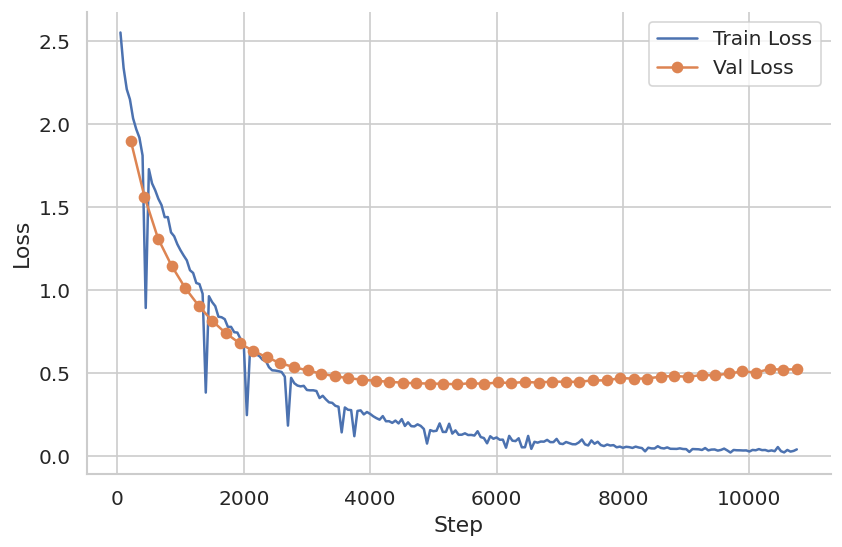

In [30]:
train_loss = ea.Scalars("train_total_loss")
val_loss   = ea.Scalars("val_total_loss")

train_steps = [x.step for x in train_loss]
train_vals  = [x.value for x in train_loss]

val_steps = [x.step for x in val_loss]
val_vals  = [x.value for x in val_loss]

plt.figure(figsize=(8,5))
plt.plot(train_steps, train_vals, label="Train Loss")
plt.plot(val_steps, val_vals, label="Val Loss", marker="o")

plt.xlabel("Step")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator
import glob, os

def load_tb_scalars(events_file, tags):
    ea = EventAccumulator(events_file, size_guidance={'scalars': 0})
    ea.Reload()
    available = ea.Tags()['scalars']
    result = {}
    for tag in tags:
        if tag in available:
            events = ea.Scalars(tag)
            result[tag] = pd.DataFrame({'step': [e.step for e in events],
                                        'value': [e.value for e in events]})
    return result

def load_all_tb(root, exp_name, dataset='Complete_Concept_FMNIST', tags=None):
    """Load TensorBoard scalars for ALL seeds of one experiment, any dataset."""
    if tags is None:
        tags = ['train_task_loss', 'train_concept_loss', 'train_total_loss',
                'val_task_loss', 'val_total_loss']
    exp_dir = root / dataset / 'train_cbm' / 'mCREAM_GraphEnsemble' / exp_name
    if not exp_dir.exists():
        print(f'Not found: {exp_dir}'); return {}
    all_data = {}
    for seed_dir in sorted(exp_dir.glob('seed_*')):
        seed = int(seed_dir.name.split('_')[1])
        for version_dir in sorted(seed_dir.glob('lightning_logs/version_*')):
            for ef in sorted(version_dir.glob('events.out.tfevents.*')):
                try:
                    data = load_tb_scalars(str(ef), tags)
                    if any('train' in k for k in data):
                        all_data[seed] = data
                        break
                except: pass
    print(f'{dataset}/{exp_name}: loaded {len(all_data)} seeds')
    return all_data


def plot_tb_loss(all_data, title, fname,
                 tags=('train_task_loss', 'train_concept_loss', 'train_total_loss')):
    if not all_data: print('No TensorBoard data'); return
    avail = [t for t in tags if any(t in d for d in all_data.values())]
    if not avail: return

    LOSS_COLOR = {'train_task_loss':    '#e74c3c',
                  'train_concept_loss': '#3498db',
                  'train_total_loss':   '#2c3e50',
                  'val_task_loss':      '#e67e22',
                  'val_total_loss':     '#8e44ad'}

    fig, axes = plt.subplots(1, len(avail), figsize=(5*len(avail), 4), sharey=False)
    if len(avail) == 1: axes = [axes]
    fig.suptitle(f'{title}\n(mean ± std across {len(all_data)} seeds, faint = individual seeds)',
                 fontsize=10, fontweight='bold')

    for ax, tag in zip(axes, avail):
        col = LOSS_COLOR.get(tag, '#555555')
        seed_dfs = []
        for seed, data in all_data.items():
            if tag not in data: continue
            df = data[tag].rename(columns={'value': seed})
            seed_dfs.append(df.set_index('step'))
            ax.plot(df['step'], df[seed], color=col, lw=0.7, alpha=0.3)
        if seed_dfs:
            combined = pd.concat(seed_dfs, axis=1)
            mean = combined.mean(axis=1); std = combined.std(axis=1)
            ax.plot(mean.index, mean.values, color=col, lw=2.5)
            ax.fill_between(mean.index, mean-std, mean+std, alpha=0.2, color=col)
        ax.set_title(tag.replace('train_','').replace('_loss','').replace('_',' '), fontsize=9)
        ax.set_xlabel('Step'); ax.set_ylabel('Loss'); ax.tick_params(labelsize=8)

    plt.tight_layout()
    plt.savefig(f'{fname}.png', dpi=150, bbox_inches='tight')
    plt.show()


# ── Exp2: cfmnist edge count ──────────────────────────────────────────────────
show_counts = [12, 15, 17, 19, 22]
for count in show_counts:
    exp_name = f'gensemble_edge_count_u2c_{count}edges'
    tb_data  = load_all_tb(EXPERIMENTS_ROOT, exp_name, dataset='Complete_Concept_FMNIST')
    if tb_data:
        plot_tb_loss(tb_data,
                     title=f'Exp2 cfmnist: Training loss — {count} u2c edges{"  (GT)" if count==17 else ""}',
                     fname=f'tb_lc_exp2_{count}edges')

# ── Exp4: Consensus — all datasets × all levels ───────────────────────────────
for ds in list(DATASET_CONFIG.keys()):
    for level in LEVELS:
        exp_name = f'graph_ensemble_consensus_{level}'
        tb_data  = load_all_tb(EXPERIMENTS_ROOT, exp_name, dataset=ds)
        if tb_data:
            plot_tb_loss(tb_data,
                         title=f'Exp4 {ds}: Training loss — consensus {level}',
                         fname=f'tb_lc_exp4_{ds.replace(" ","_")}_{level}')

In [19]:
# ── Exp2: all edge counts overlaid on one plot per loss ──────────────────────
if len(lc_exp2) == 0:
    print('No Exp2 learning curves yet.')
else:
    lc_exp2['edge_count'] = lc_exp2['exp_name'].apply(
        lambda x: int(_re.search(r'(\d+)edges', x).group(1)) if _re.search(r'(\d+)edges', x) else None)
    lc_exp2 = lc_exp2.dropna(subset=['edge_count', 'epoch'])
    lc_exp2['edge_count'] = lc_exp2['edge_count'].astype(int)

    avail = [c for c in LOSS_COLS if c in lc_exp2.columns]
    if avail:
        all_counts = sorted(lc_exp2['edge_count'].unique())
        show_counts = [c for c in [12, 15, 17, 19, 22] if c in all_counts] or all_counts
        cmap = plt.cm.RdYlGn

        fig, axes = plt.subplots(1, len(avail), figsize=(5*len(avail), 4.5), sharey=False)
        if len(avail) == 1: axes = [axes]
        fig.suptitle('Exp2: Learning Curves per Edge Count\n'
                     f'(GT=17, each line = mean across seeds)',
                     fontsize=11, fontweight='bold')

        for ax, loss in zip(axes, avail):
            for count in show_counts:
                sub = lc_exp2[lc_exp2['edge_count'] == count].dropna(subset=[loss])
                if sub.empty: continue
                agg = sub.groupby('epoch')[loss].agg(['mean','std']).reset_index()
                norm = all_counts.index(count) / max(len(all_counts)-1, 1)
                col  = cmap(norm)
                lw   = 3 if count == 17 else 1.5
                ls   = '-' if count == 17 else '--'
                ax.plot(agg['epoch'], agg['mean'], color=col, lw=lw, ls=ls,
                        label=f'{count}{"(GT)" if count==17 else ""}')
                ax.fill_between(agg['epoch'], agg['mean']-agg['std'], agg['mean']+agg['std'],
                                alpha=0.08, color=col)
            ax.set_title(loss.replace('train_','').replace('_loss','').replace('_',' '), fontsize=9)
            ax.set_xlabel('Epoch'); ax.set_ylabel('Loss'); ax.tick_params(labelsize=8)
            ax.legend(fontsize=7, ncol=2)

        plt.tight_layout()
        plt.savefig('lc_exp2_edge_count.png', dpi=150, bbox_inches='tight')
        plt.show()

KeyError: ['epoch']

---
# Cross-Experiment Comparison

Direct comparison of all three experiments.


In [ ]:
# Collect one row per experiment type with key metrics
summary_rows = []
if len(exp1_df)>0 and 'test_task_accuracy' in exp1_df.columns:
    for (action,level),grp in exp1_df.groupby(['action','noise_level']):
        summary_rows.append({'experiment':'Noisy DAG','action':action,'level':level,
            'task_acc':grp['test_task_accuracy'].mean(),
            'concept_acc':grp.get('test_concept_accuracy',pd.Series([float('nan')])).mean(),
            'CCI':grp['CCI'].mean() if 'CCI' in grp.columns else float('nan')})
if len(exp3_df)>0 and 'test_task_accuracy' in exp3_df.columns:
    for action,grp in exp3_df.groupby('action'):
        summary_rows.append({'experiment':'Mixed Levels','action':action,'level':'mixed',
            'task_acc':grp['test_task_accuracy'].mean(),
            'concept_acc':grp.get('test_concept_accuracy',pd.Series([float('nan')])).mean(),
            'CCI':grp['CCI'].mean() if 'CCI' in grp.columns else float('nan')})
if len(gt_df)>0:
    summary_rows.append({'experiment':'GT CREAM','action':'—','level':'—',
        'task_acc':gt_df['test_task_accuracy'].mean(),
        'concept_acc':gt_df.get('test_concept_accuracy',pd.Series([float('nan')])).mean(),
        'CCI':gt_df['CCI'].mean() if 'CCI' in gt_df.columns else float('nan')})
if summary_rows:
    print('=== Cross-experiment summary ===')
    display(pd.DataFrame(summary_rows).round(4))


Loaded alpha for 3 experiments, seeds: [1, 7, 42, 89, 134]


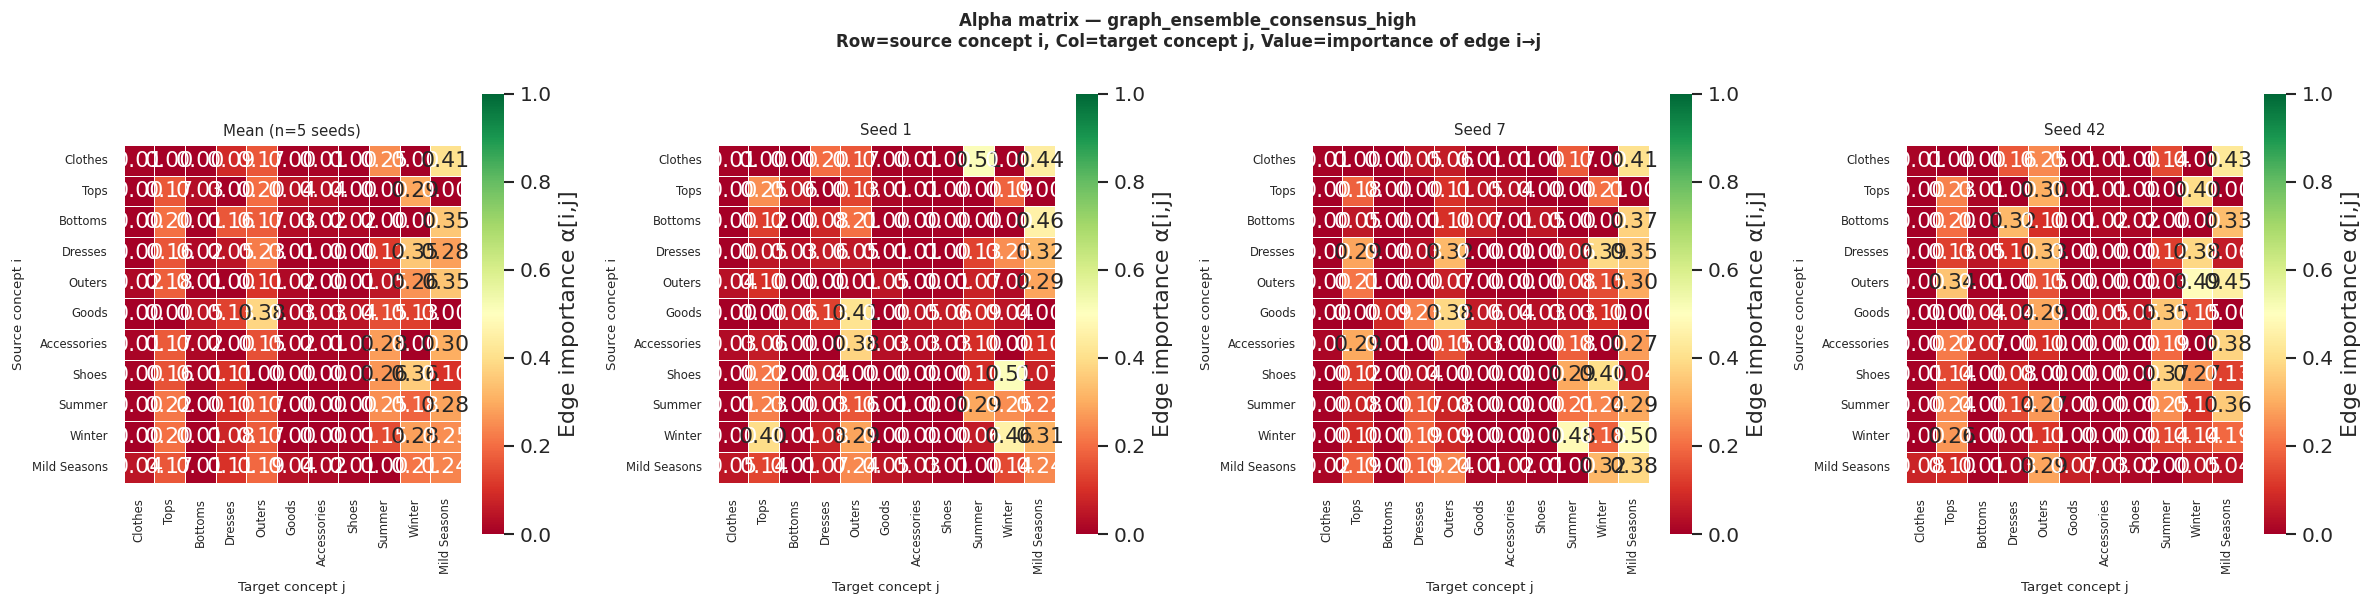


--- graph_ensemble_consensus_high: Top 5 most important edges (mean α) ---
  Clothes → Mild Seasons: α=0.408 ± 0.066
  Goods → Outers: α=0.383 ± 0.048
  Shoes → Winter: α=0.363 ± 0.087
  Bottoms → Mild Seasons: α=0.351 ± 0.073
  Dresses → Winter: α=0.348 ± 0.050

--- Bottom 5 (suppressed by L1) ---
  Goods → Mild Seasons: α=0.003
  Goods → Clothes: α=0.003
  Dresses → Clothes: α=0.003
  Outers → Dresses: α=0.003
  Summer → Bottoms: α=0.002


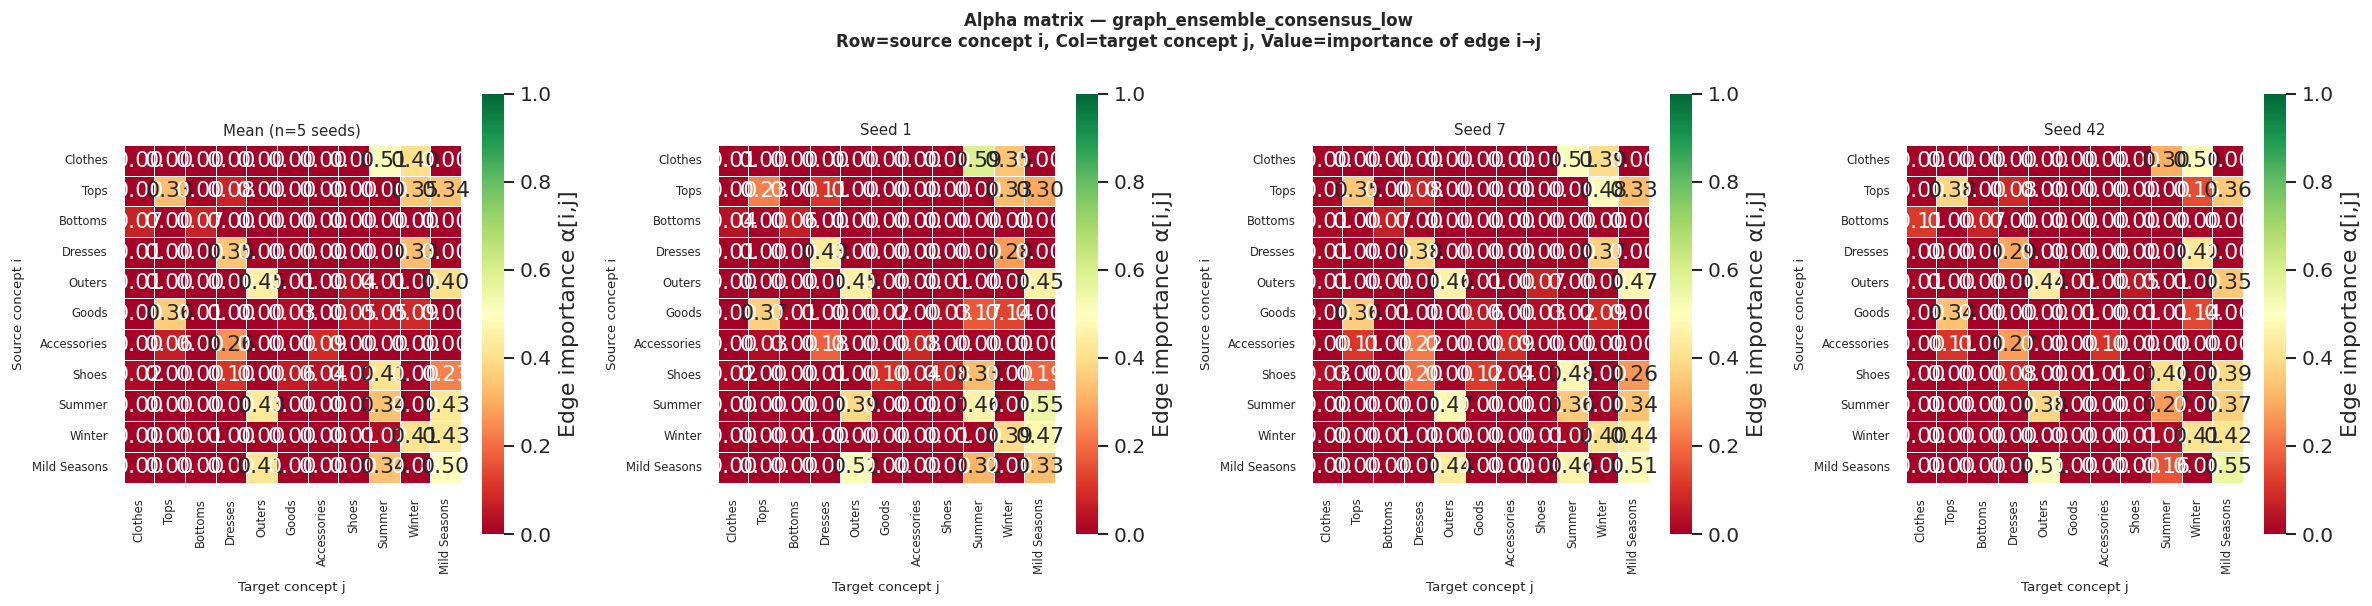


--- graph_ensemble_consensus_low: Top 5 most important edges (mean α) ---
  Clothes → Summer: α=0.511 ± 0.108
  Mild Seasons → Mild Seasons: α=0.503 ± 0.092
  Outers → Outers: α=0.447 ± 0.032
  Summer → Outers: α=0.431 ± 0.038
  Winter → Mild Seasons: α=0.428 ± 0.027

--- Bottom 5 (suppressed by L1) ---
  Accessories → Bottoms: α=0.003
  Summer → Bottoms: α=0.003
  Clothes → Goods: α=0.002
  Accessories → Clothes: α=0.002
  Winter → Accessories: α=0.002


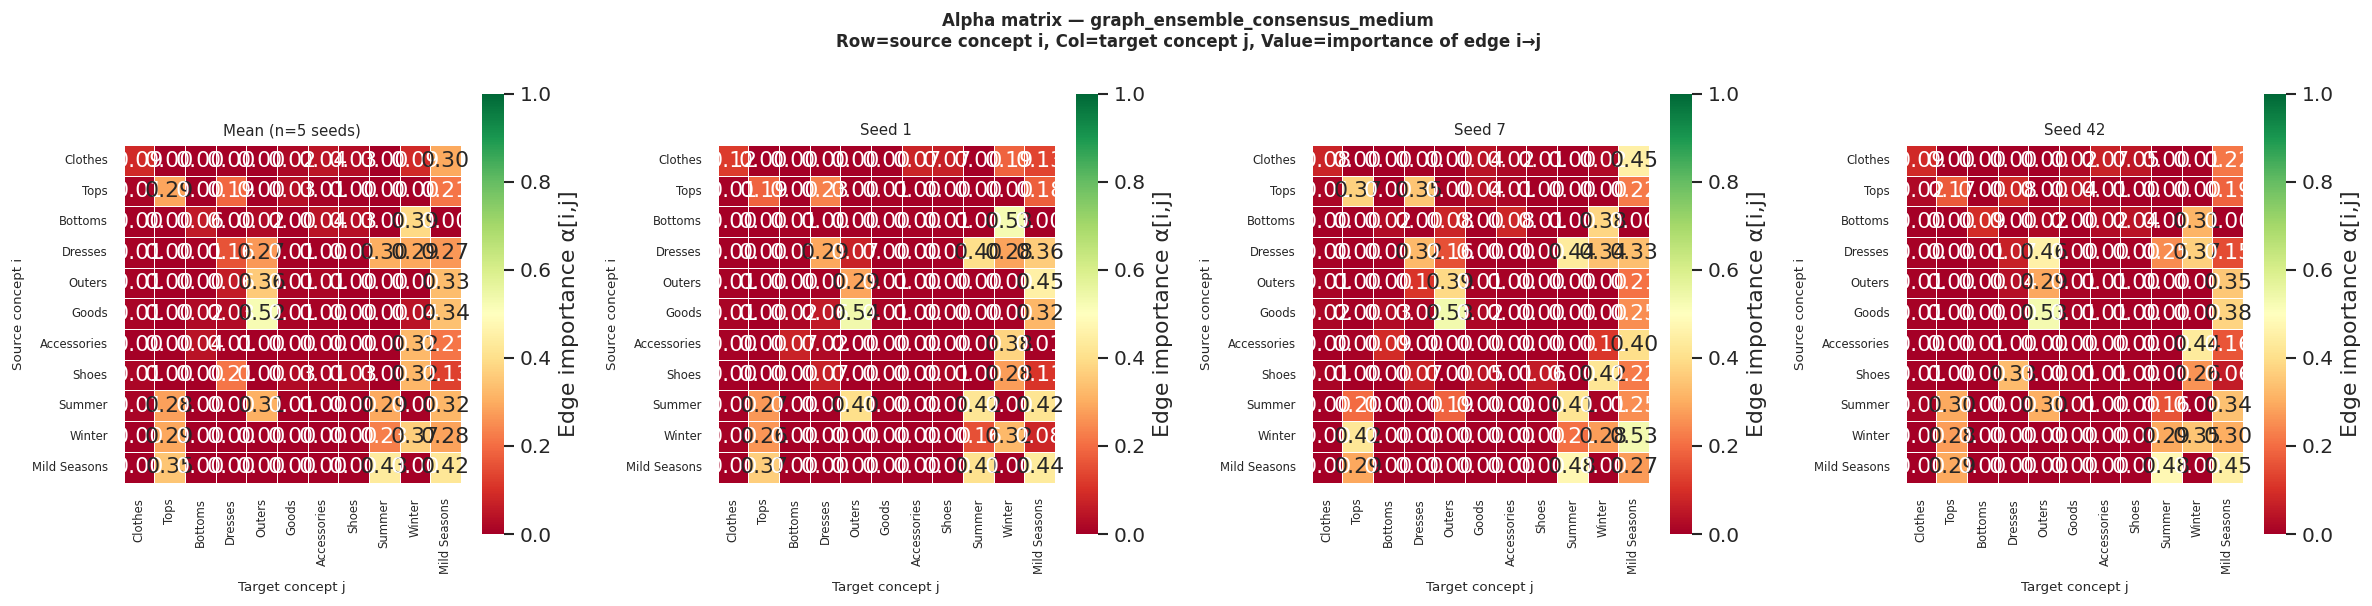


--- graph_ensemble_consensus_medium: Top 5 most important edges (mean α) ---
  Goods → Outers: α=0.523 ± 0.013
  Mild Seasons → Summer: α=0.435 ± 0.051
  Mild Seasons → Mild Seasons: α=0.424 ± 0.082
  Bottoms → Winter: α=0.390 ± 0.093
  Winter → Winter: α=0.366 ± 0.073

--- Bottom 5 (suppressed by L1) ---
  Shoes → Bottoms: α=0.003
  Tops → Shoes: α=0.003
  Shoes → Outers: α=0.003
  Shoes → Summer: α=0.003
  Tops → Summer: α=0.003
